### BOI

Loaded signal
dataset_name : 2018
signal_index : 1
batch_dir    : 1
tim_path     : ../../../CSPB.ML_dataset/CSPB_ML_2018_Data/Batch_Dir_1/signal_1.tim
x.shape      : (32768,)
P_total      : 1.9975691527

Truth labels are printed only for checking; Step A/B below do not use them.
signal_index                : 1
signal_type                 : bpsk
base_symbol_period          : 11.0
T0_eff                      : 12.222222222222221
symbol_rate                 : 0.08181818181818182
carrier_offset_label        : -0.0007443346708
excess_bw                   : 0.98977795076
upsample                    : 10.0
downsample                  : 9.0
inband_snr_db_label         : 7.8834556169
noise_spectral_density_db_label: 0.0

Step A0: fixed_resolution_boi() result
N                 : 32768
df                : 3.0517578125e-05
DELTA_F0          : 0.002
W                 : 65 bins
threshold_db      : 5.0 dB
q_linear          : 3.162278
S_min             : 1.8224063325e-05
threshold_F       : 5.7629548

,id,left_bin,right_bin,width_bins,f_left,f_right,f_center,bandwidth,power_raw,noise_power_hat_raw,signal_power_hat_raw,power_smooth_blog,signal_power_hat_smooth
0,0,14166,18553,4388,-0.067688,0.066193,-0.000748,0.133911,1.128683,0.134352,0.994331,1.128472,0.994054



Selected / refined BOIs

Initial selected BOI:
left_bin                        : 14166
right_bin                       : 18553
width_bins                      : 4388
f_left                          : -6.7687988281e-02
f_right                         : 6.6192626953e-02
f_center                        : -7.4768066406e-04
bandwidth                       : 1.3391113281e-01
power_smooth_blog               : 1.1284718830e+00
power_raw                       : 1.1286832967e+00
noise_power_hat_raw             : 1.3435226815e-01
signal_power_hat_raw            : 9.9433102859e-01
noise_power_hat_smooth          : 1.3441746008e-01
signal_power_hat_smooth         : 9.9405442294e-01
excess_power_score              : 9.9433102859e-01

Merged BOI:
left_bin                        : 14166
right_bin                       : 18553
width_bins                      : 4388
f_left                          : -6.7687988281e-02
f_right                         : 6.6192626953e-02
f_center                        : -

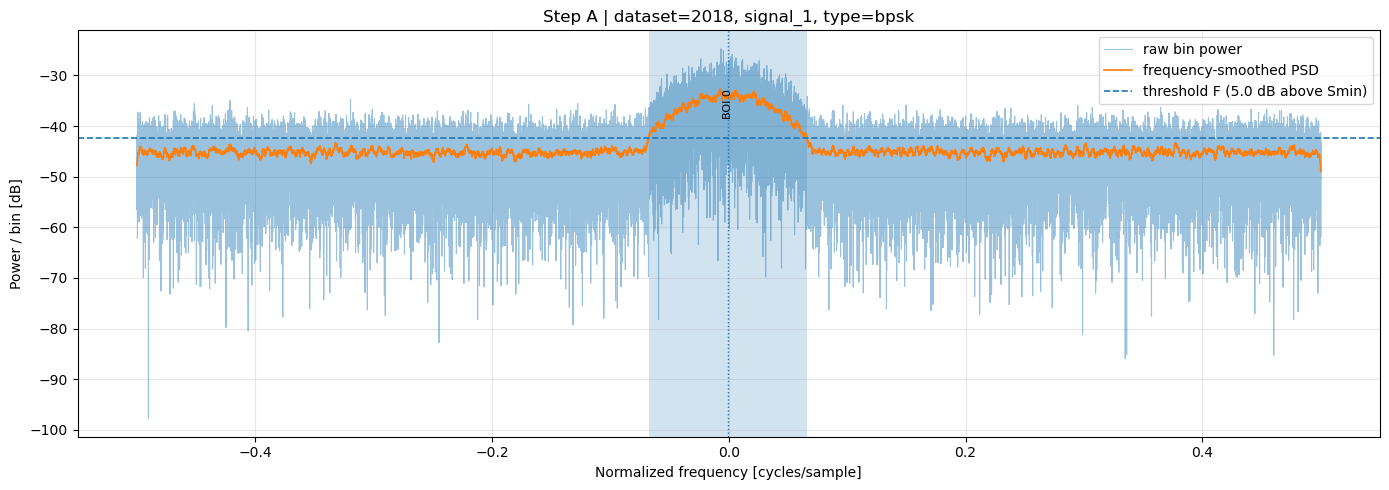

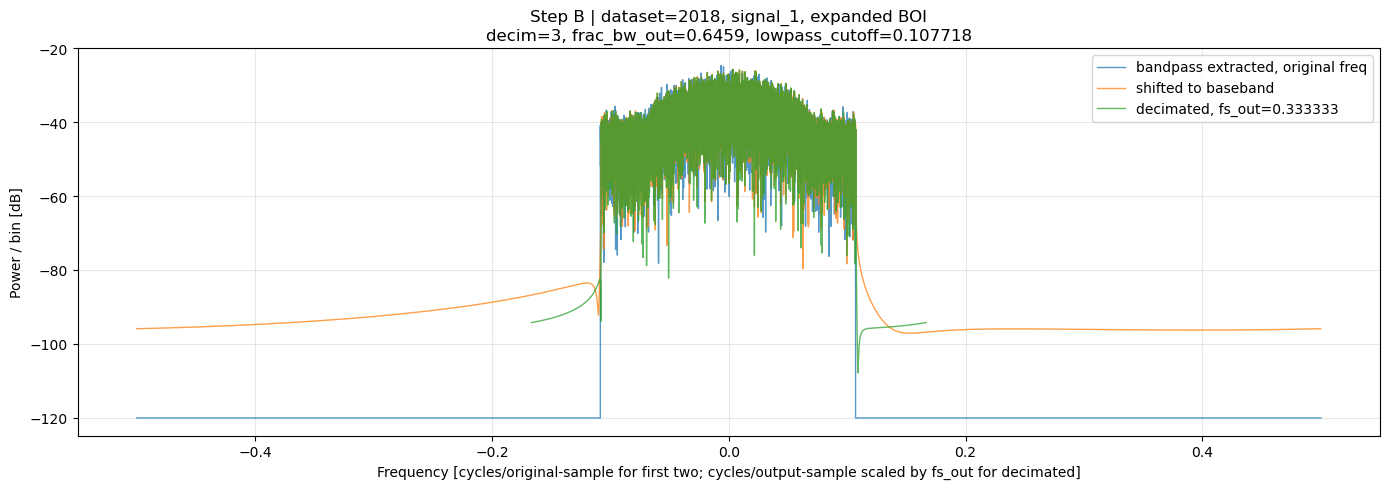


Compact Step 1-3 Report
[Loaded] dataset=2018 | signal=1 | type=bpsk | label_SNR=7.883 dB | P_total=1.997569
[BOI] center=-6.237801e-04 | label_CFO=-7.443347e-04 | center_err=1.206e-04 | smooth_res=1.984e-03 | method=excess_power_centroid
[BW] truth=0.162800 | refined=0.165649 (1.018x) | filter=0.215314 (1.323x) | expand=0.150
[Power] P_sig_boi=0.998042 | P_sig_rec=0.994275 | P_noise_in=0.166195 | P_noise_out=0.837099 | BOI_residual=-3.767e-03 (-0.189%)
[SNR] BOI=7.785 dB (err=-0.098) | recommended=7.769 dB (err=-0.115)
[Step B no-resample] decim=1 | fs_out=1.000000 | frac_bw=0.215 | x_processed=(32768,) | P_bpf=1.215492 | P_baseband=1.215492
[Step B decimated ref] decim=3 | fs_out=0.333333 | frac_bw=0.646 | x_decimated=(10923,) | P_dec=1.215216
[Status] center=PASS | SNR=PASS | frac_bw=PASS
[MR level 0] fs=1, center_global=+0.000000e+00, prev_bw=1, new_bw=0.215314, rel_change=0.785, completed=False
[MR level 1] fs=0.333333, center_global=-6.237801e-04, prev_bw=0.215314, new_bw=0.2892

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Config
# ============================================================

DATASET_NAME = "2018"   # "2018" or "2022"

ROOT_MAP = {
    "2022": "../../../CSPB.ML_dataset/CSPB_ML_2022_Data",
    "2018": "../../../CSPB.ML_dataset/CSPB_ML_2018_Data",
}

LABEL_MAP = {
    "2022": "CSPB_ML_2022_Signal_Truth_Labels.txt",
    "2018": "CSPB_ML_2018_Signal_Truth_Labels.txt",
}

FS_IN = 1.0
N_PER_BATCH = 4000
N_BATCHES = 28
N_TOTAL = N_PER_BATCH * N_BATCHES
SAMPLES_PER_SIG = 32768
EPS = 1e-12

# Blog / paper style parameters
DELTA_F0 = 0.002          # normalized spectral resolution, used as W = floor(T * DELTA_F0)
# ============================================================
# BOI detection / refinement parameters
# ============================================================

# High threshold: stable initial BOI detection.
THRESHOLD_DB = 5.0

# Low threshold: expand the selected BOI boundary to include weak roll-off energy.
# Try 2.0 first. If low-SNR bandwidth is still too narrow, use 1.5 or 1.0.
BOUNDARY_THRESHOLD_DB = 1.5

# Merge small BOIs near the selected main BOI if the gap is not large.
MERGE_GAP_W_FACTOR = 2.0

# Prevent unlimited edge expansion.
MAX_EXPAND_W_FACTOR = 8.0

# Step B filtering uses an expanded BOI so that roll-off edges are not cut.
FILTER_EXPAND_RATIO = 0.20
# ============================================================
# Adaptive filter expansion
# ============================================================
# 根据 blind estimated SNR 自适应扩展 filter BOI：
# 低 SNR：多扩一点，避免切掉弱 roll-off 边缘
# 高 SNR：少扩一点，避免引入过多额外噪声
ADAPTIVE_FILTER_EXPAND = True

FILTER_EXPAND_RATIO_LOW_SNR  = 0.30
FILTER_EXPAND_RATIO_MID_SNR  = 0.15
FILTER_EXPAND_RATIO_HIGH_SNR = 0.05

SNR_LOW_TH_DB  = 4.0
SNR_HIGH_TH_DB = 8.0
# Decimation should be conservative after expansion.
# 0.97 is too aggressive for low SNR because BW estimates are uncertain.
TARGET_FRAC_BW = 0.85

BOI_GUARD_BINS = 2
# ============================================================
# Step C: Multiresolution BOI parameters
# ============================================================

ENABLE_MULTIRESOLUTION = True

MAX_MR_LEVELS = 4

# If current detected filter bandwidth is close to the previous extracted bandwidth,
# we consider the BOI completed.
MR_STOP_BW_REL_TOL = 0.12

# If center correction between consecutive levels is tiny, that supports stopping.
MR_STOP_CENTER_ABS_TOL = 2.0 * DELTA_F0

# CSPB.ML is one-signal-per-record, so strongest branch is enough.
MR_BRANCH_MODE = "strongest"
# ============================================================
# MR accept / fallback policy
# ============================================================

# MR final BOI is allowed to grow only slightly relative to Fixed filter BOI.
MR_MAX_ACCEPTED_GROWTH = 0.05   # 5%

# MR must not make recommended SNR worse by more than this amount.
MR_MAX_SNR_DEGRADATION_DB = 0.25

# MR center improvement must be meaningful if bandwidth does not improve.
MR_MIN_CENTER_IMPROVEMENT_RATIO = 0.20  # at least 20% lower center error

# If True, choose Fixed unless MR clearly improves.
USE_FIXED_AS_DEFAULT = True
# ============================================================
# Dataset loading only
# ============================================================

def set_dataset(dataset_name: str):
    if dataset_name not in ROOT_MAP:
        raise ValueError(f"Unsupported dataset_name={dataset_name}. Use '2018' or '2022'.")
    root_data = ROOT_MAP[dataset_name]
    label_path = os.path.join(root_data, LABEL_MAP[dataset_name])
    truth_df = load_truth_labels(label_path).set_index("SignalIndex", drop=False)
    return root_data, label_path, truth_df


def load_truth_labels(label_path: str) -> pd.DataFrame:
    """
    Read CSPB.ML truth-label txt file.

    Expected columns:
      SignalIndex SignalType BaseSymbolPeriod CarrierOffset
      ExcessBandwidth UpsampleFactor DownsampleFactor
      InbandSNRdB NoiseSpectralDensitydB
    """
    df = pd.read_csv(label_path, sep=r"\s+")

    expected = [
        "SignalIndex", "SignalType", "BaseSymbolPeriod", "CarrierOffset",
        "ExcessBandwidth", "UpsampleFactor", "DownsampleFactor",
        "InbandSNRdB", "NoiseSpectralDensitydB"
    ]
    if list(df.columns) != expected:
        raise ValueError(
            f"Unexpected label columns.\n"
            f"Got     : {list(df.columns)}\n"
            f"Expected: {expected}"
        )

    df["SignalType"] = df["SignalType"].astype(str).str.lower()

    # Effective symbol rate after CSPB.ML resamp step:
    # Rs = D / (U * BaseSymbolPeriod)
    D = df["DownsampleFactor"].to_numpy(dtype=np.float64)
    U = df["UpsampleFactor"].to_numpy(dtype=np.float64)
    Tbase = df["BaseSymbolPeriod"].to_numpy(dtype=np.float64)

    D_eff = np.where(D == 0, 1.0, D)
    U_eff = np.where(U == 0, 1.0, U)

    Rs = D_eff / (U_eff * Tbase)
    df["SymbolRate"] = Rs
    df["T0_eff"] = 1.0 / Rs
    df["CFO"] = df["CarrierOffset"].astype(np.float64)

    return df


def get_truth_params(truth_df: pd.DataFrame, signal_index: int):
    if signal_index not in truth_df.index:
        raise ValueError(f"Signal index {signal_index} not found in truth labels.")

    row = truth_df.loc[signal_index]

    return {
        "signal_index": int(row["SignalIndex"]),
        "signal_type": str(row["SignalType"]),
        "base_symbol_period": float(row["BaseSymbolPeriod"]),
        "T0_eff": float(row["T0_eff"]),
        "symbol_rate": float(row["SymbolRate"]),
        "carrier_offset_label": float(row["CarrierOffset"]),
        "excess_bw": float(row["ExcessBandwidth"]),
        "upsample": float(row["UpsampleFactor"]),
        "downsample": float(row["DownsampleFactor"]),
        "inband_snr_db_label": float(row["InbandSNRdB"]),
        "noise_spectral_density_db_label": float(row["NoiseSpectralDensitydB"]),
    }


def global_to_path(root_data: str, gidx: int):
    """
    1-based global signal index -> .tim path.
    """
    if gidx < 1 or gidx > N_TOTAL:
        raise ValueError(f"global index out of range: {gidx} (valid 1..{N_TOTAL})")

    batch_dir = (gidx - 1) // N_PER_BATCH + 1
    tim_path = os.path.join(root_data, f"Batch_Dir_{batch_dir}", f"signal_{gidx}.tim")
    return tim_path, batch_dir


def tim_to_complex_iq_32768(tim_path: str) -> np.ndarray:
    """
    Read one .tim file:
      first 2 float32 are metadata,
      then 32768 complex samples stored as interleaved float32 I,Q.
    """
    raw = np.fromfile(tim_path, dtype=np.float32)
    need = 2 + 2 * SAMPLES_PER_SIG
    if raw.size < need:
        raise ValueError(f"{tim_path}: {raw.size} floats < {need}")

    iq = raw[2:need]
    I = iq[0::2].astype(np.float64)
    Q = iq[1::2].astype(np.float64)
    x = I + 1j * Q

    if x.size != SAMPLES_PER_SIG:
        raise ValueError(f"{tim_path}: expected {SAMPLES_PER_SIG} IQ samples, got {x.size}")

    return x.astype(np.complex128)


def signal_rms_power(x):
    x = np.asarray(x, dtype=np.complex128)
    return float(np.mean(np.abs(x) ** 2))


# ============================================================
# Utilities
# ============================================================

def fftshift_freqs(n: int, fs: float = 1.0):
    return np.fft.fftshift(np.fft.fftfreq(n, d=1.0 / fs))


def moving_average_same(x, w: int):
    """
    Frequency smoothing by rectangular moving average.
    Returns same length as x.

    The algorithm's valid test region is still restricted to:
      [W/2, T-W/2)
    so edge artifacts are not used for threshold decisions.
    """
    x = np.asarray(x, dtype=np.float64)
    w = int(max(1, w))
    if w == 1:
        return x.copy()

    kernel = np.ones(w, dtype=np.float64) / float(w)
    return np.convolve(x, kernel, mode="same")


def contiguous_true_runs(mask):
    """
    Return inclusive [start, stop] index pairs for True-runs.
    """
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []

    padded = np.r_[False, mask, False]
    changes = np.diff(padded.astype(np.int8))
    starts = np.where(changes == 1)[0]
    stops = np.where(changes == -1)[0] - 1

    return list(zip(starts, stops))


def interval_mask(n, left, right):
    m = np.zeros(n, dtype=bool)
    m[int(left):int(right) + 1] = True
    return m


def wrap_freq_to_nyquist(f):
    """
    Wrap normalized frequency to [-0.5, 0.5).
    """
    return ((f + 0.5) % 1.0) - 0.5


# ============================================================
# Step A: Fixed-resolution BOI detector
# ============================================================

def fixed_resolution_boi(
    x,
    fs=1.0,
    delta_f0=DELTA_F0,
    threshold_db=THRESHOLD_DB,
    min_width_bins=2,
    keep_weak=True,
):
    """
    Step A: fixed-resolution BOI detector.

    Implements the blog/paper fixed-resolution idea:
      1. Obtain samples x(i)
      2. Specify resolution delta_f0
      3. W = floor(T * delta_f0)
      4. Compute frequency-smoothed periodogram S(j)
      5. S_min = min S(j), excluding edges
      6. F = q * S_min
      7-11. Find contiguous above-threshold intervals
      12. Estimate noise floor from non-BOI bins
      13. Estimate BOI power by summing PSD bins
      14. Weak BOI removal is not specified in the paper/blog;
          this function keeps all detected BOIs by default.

    PSD convention:
      raw_bin_power = |FFT{x}|^2 / N^2
    Therefore:
      sum(raw_bin_power) ~= mean(|x|^2)
    """
    x = np.asarray(x, dtype=np.complex128)
    n = x.size

    if n < 8:
        raise ValueError("Input x is too short.")

    # Frequency grid
    freqs = fftshift_freqs(n, fs=fs)
    df = fs / n

    # Raw per-bin power periodogram
    X = np.fft.fftshift(np.fft.fft(x))
    raw_bin_power = (np.abs(X) ** 2) / (n ** 2)

    # Frequency-smoothed periodogram
    W = int(np.floor(n * float(delta_f0)))
    W = max(1, W)
    if W % 2 == 0:
        W += 1

    S = moving_average_same(raw_bin_power, W)

    half = W // 2
    valid_left = half
    valid_right = n - half   # exclusive

    if valid_right <= valid_left:
        raise ValueError(f"Invalid smoothing width W={W} for n={n}.")

    valid_slice = slice(valid_left, valid_right)
    S_valid = S[valid_slice]

    # Algorithm threshold F = q * S_min
    q = 10.0 ** (threshold_db / 10.0)
    S_min = float(np.min(S_valid))
    F = q * S_min

    # Above threshold = BOI candidate
    boi_mask_valid = S_valid >= F
    runs_valid = contiguous_true_runs(boi_mask_valid)

    boi_list = []
    full_boi_mask = np.zeros(n, dtype=bool)

    for local_l, local_r in runs_valid:
        left = valid_left + local_l
        right = valid_left + local_r

        # Edge handling, matching the spirit of steps 10-11
        if local_l == 0:
            left = 0
        if local_r == len(boi_mask_valid) - 1:
            right = n - 1

        width_bins = int(right - left + 1)
        if width_bins < min_width_bins:
            continue

        m = interval_mask(n, left, right)
        full_boi_mask |= m

        # Blog/paper BOI power: sum PSD values inside BOI.
        # We report both smoothed-PSD power and raw per-bin power.
        power_smooth = float(np.sum(S[m]))
        power_raw = float(np.sum(raw_bin_power[m]))

        f_left = float(freqs[left])
        f_right = float(freqs[right])
        bandwidth = float((right - left + 1) * df)

        # Center by midpoint of endpoints
        f_center = wrap_freq_to_nyquist(0.5 * (f_left + f_right))

        boi_list.append({
            "left_bin": int(left),
            "right_bin": int(right),
            "width_bins": width_bins,
            "f_left": f_left,
            "f_right": f_right,
            "f_center": float(f_center),
            "bandwidth": bandwidth,
            "power_smooth_blog": power_smooth,
            "power_raw": power_raw,
        })

    # Noise floor estimate: average PSD outside BOI intervals
    non_boi_mask = ~full_boi_mask
    # Avoid using extreme invalid edges for noise estimate if possible
    valid_mask_full = np.zeros(n, dtype=bool)
    valid_mask_full[valid_left:valid_right] = True
    noise_mask = non_boi_mask & valid_mask_full

    if np.any(noise_mask):
        noise_floor_smooth_per_bin = float(np.mean(S[noise_mask]))
        noise_floor_raw_per_bin = float(np.mean(raw_bin_power[noise_mask]))
    else:
        # fallback if everything is detected as BOI
        noise_floor_smooth_per_bin = float(S_min)
        noise_floor_raw_per_bin = float(np.min(raw_bin_power[valid_slice]))

    # Add estimated in-band noise and signal power to each BOI
    for b in boi_list:
        noise_power_hat_raw = noise_floor_raw_per_bin * b["width_bins"]
        signal_power_hat_raw = max(b["power_raw"] - noise_power_hat_raw, 0.0)

        b["noise_power_hat_raw"] = float(noise_power_hat_raw)
        b["signal_power_hat_raw"] = float(signal_power_hat_raw)

        noise_power_hat_smooth = noise_floor_smooth_per_bin * b["width_bins"]
        signal_power_hat_smooth = max(b["power_smooth_blog"] - noise_power_hat_smooth, 0.0)

        b["noise_power_hat_smooth"] = float(noise_power_hat_smooth)
        b["signal_power_hat_smooth"] = float(signal_power_hat_smooth)

        # Useful score for selecting strongest BOI
        b["excess_power_score"] = float(signal_power_hat_raw)

    # Optional weak BOI removal.
    # The paper/blog states "Remove weak BOIs" but does not specify the rule,
    # so by default keep_weak=True keeps all BOIs.
    if not keep_weak:
        boi_list = [b for b in boi_list if b["signal_power_hat_raw"] > 0.0]

    # Sort by frequency for display; strongest can be selected later.
    boi_list = sorted(boi_list, key=lambda d: d["f_left"])

    return {
        "fs": float(fs),
        "n": int(n),
        "df": float(df),
        "delta_f0": float(delta_f0),
        "W": int(W),
        "threshold_db": float(threshold_db),
        "q_linear": float(q),
        "S_min": float(S_min),
        "threshold_F": float(F),
        "freqs": freqs,
        "raw_bin_power": raw_bin_power,
        "S_smooth": S,
        "valid_left": int(valid_left),
        "valid_right": int(valid_right),
        "boi_mask": full_boi_mask,
        "noise_floor_smooth_per_bin": noise_floor_smooth_per_bin,
        "noise_floor_raw_per_bin": noise_floor_raw_per_bin,
        "bois": boi_list,
    }


def select_boi(boi_result, mode="strongest"):
    """
    Select one BOI for Step B.
    For CSPB.ML, one signal per record is expected, so strongest BOI is usually appropriate.
    """
    bois = boi_result["bois"]
    if len(bois) == 0:
        raise RuntimeError("No BOI detected.")

    if mode == "strongest":
        return max(bois, key=lambda b: b["excess_power_score"])

    if mode == "widest":
        return max(bois, key=lambda b: b["width_bins"])

    if mode == "first":
        return bois[0]

    raise ValueError(f"Unknown select mode: {mode}")
# ============================================================
# Step A improvements:
#   1) recompute BOI metrics
#   2) merge nearby BOI fragments
#   3) hysteresis edge refinement
#   4) optional expanded BOI for Step B filtering
# ============================================================

def recompute_boi_metrics(boi_result, left, right, tag=None):
    """
    Recompute BOI metrics for interval [left, right] using the original PSD arrays.
    """
    n = boi_result["n"]
    df = boi_result["df"]
    freqs = boi_result["freqs"]
    raw = boi_result["raw_bin_power"]
    S = boi_result["S_smooth"]

    left = int(max(0, min(left, n - 1)))
    right = int(max(0, min(right, n - 1)))
    if right < left:
        left, right = right, left

    m = interval_mask(n, left, right)
    width_bins = int(right - left + 1)

    power_raw = float(np.sum(raw[m]))
    power_smooth = float(np.sum(S[m]))

    noise_power_hat_raw = float(boi_result["noise_floor_raw_per_bin"] * width_bins)
    signal_power_hat_raw = float(max(power_raw - noise_power_hat_raw, 0.0))

    noise_power_hat_smooth = float(boi_result["noise_floor_smooth_per_bin"] * width_bins)
    signal_power_hat_smooth = float(max(power_smooth - noise_power_hat_smooth, 0.0))

    b = {
        "left_bin": int(left),
        "right_bin": int(right),
        "width_bins": int(width_bins),
        "f_left": float(freqs[left]),
        "f_right": float(freqs[right]),
        "f_center": float(wrap_freq_to_nyquist(0.5 * (freqs[left] + freqs[right]))),
        "bandwidth": float(width_bins * df),
        "power_smooth_blog": power_smooth,
        "power_raw": power_raw,
        "noise_power_hat_raw": noise_power_hat_raw,
        "signal_power_hat_raw": signal_power_hat_raw,
        "noise_power_hat_smooth": noise_power_hat_smooth,
        "signal_power_hat_smooth": signal_power_hat_smooth,
        "excess_power_score": signal_power_hat_raw,
    }

    if tag is not None:
        b["tag"] = tag

    return b


def merge_neighbors_around_selected(
    boi_result,
    selected,
    max_gap_bins=None,
    min_neighbor_power_frac=0.001,
):
    """
    Merge small neighboring BOI fragments around the selected BOI.

    Why:
      At the SRRC roll-off edge, high-threshold detection may create tiny separated
      fragments. For Step A/B, these fragments should often be merged with the main BOI.

    Rule:
      Merge any BOI whose gap to the current selected interval is <= max_gap_bins
      and whose signal_power is not completely negligible.
    """
    bois = boi_result["bois"]
    if max_gap_bins is None:
        max_gap_bins = int(MERGE_GAP_W_FACTOR * boi_result["W"])

    left = int(selected["left_bin"])
    right = int(selected["right_bin"])

    main_power = max(float(selected["signal_power_hat_raw"]), EPS)
    changed = True

    while changed:
        changed = False

        for b in bois:
            bl = int(b["left_bin"])
            br = int(b["right_bin"])

            # Already inside current interval
            if bl >= left and br <= right:
                continue

            # Gap between b and current interval
            if br < left:
                gap = left - br - 1
            elif bl > right:
                gap = bl - right - 1
            else:
                gap = 0

            neighbor_power = float(b["signal_power_hat_raw"])
            power_ok = neighbor_power >= min_neighbor_power_frac * main_power

            if gap <= max_gap_bins and power_ok:
                left = min(left, bl)
                right = max(right, br)
                changed = True

    merged = recompute_boi_metrics(
        boi_result,
        left,
        right,
        tag="merged_neighbors"
    )
    merged["merge_max_gap_bins"] = int(max_gap_bins)
    merged["merge_min_neighbor_power_frac"] = float(min_neighbor_power_frac)

    return merged


def refine_boi_edges_hysteresis(
    boi_result,
    boi,
    boundary_threshold_db=BOUNDARY_THRESHOLD_DB,
    max_expand_bins=None,
):
    """
    Expand selected BOI edges using a lower threshold.

    High threshold finds the main BOI robustly.
    Low threshold expands boundaries to recover weak roll-off energy.

    This is the key fix for low-SNR bandwidth underestimation.
    """
    S = boi_result["S_smooth"]
    n = boi_result["n"]

    if max_expand_bins is None:
        max_expand_bins = int(MAX_EXPAND_W_FACTOR * boi_result["W"])

    q2 = 10.0 ** (boundary_threshold_db / 10.0)
    F2 = q2 * boi_result["S_min"]

    left = int(boi["left_bin"])
    right = int(boi["right_bin"])

    # Expand left
    steps = 0
    while left > 0 and S[left - 1] >= F2 and steps < max_expand_bins:
        left -= 1
        steps += 1

    # Expand right
    steps = 0
    while right < n - 1 and S[right + 1] >= F2 and steps < max_expand_bins:
        right += 1
        steps += 1

    refined = recompute_boi_metrics(
        boi_result,
        left,
        right,
        tag="hysteresis_refined"
    )
    refined["boundary_threshold_db"] = float(boundary_threshold_db)
    refined["boundary_threshold_F"] = float(F2)
    refined["max_expand_bins"] = int(max_expand_bins)

    return refined

def expand_boi_for_filtering(
    boi,
    fs=1.0,
    expand_ratio=FILTER_EXPAND_RATIO,
):
    """
    Build a wider BOI for Step B filtering.

    Important:
      - Do NOT use this expanded BOI as the only power estimate.
      - Use it for filtering / baseband extraction.
      - Keep f_center from boi. Do NOT recompute center from expanded edges,
        because expanded edges can be asymmetric/noisy and may pull the center away.
    """
    b = dict(boi)

    bw = float(boi["bandwidth"])
    guard = expand_ratio * bw

    f_left = max(float(boi["f_left"]) - guard, -fs / 2)
    f_right = min(float(boi["f_right"]) + guard, fs / 2)

    b["f_left"] = float(f_left)
    b["f_right"] = float(f_right)

    # 注意：这里保留原始 boi 的 center，通常已经是 excess-power centroid
    b["f_center"] = float(boi["f_center"])

    b["bandwidth"] = float(f_right - f_left)
    b["expanded_for_filtering"] = True
    b["filter_expand_ratio"] = float(expand_ratio)

    return b

def compute_power_report(x, boi_result, boi_for_power):
    p_total = signal_rms_power(x)
    n = boi_result["n"]

    noise_floor = float(boi_result["noise_floor_raw_per_bin"])

    boi_width_bins = int(boi_for_power["width_bins"])

    p_noise_fullband_hat = noise_floor * n
    p_noise_inband_hat = noise_floor * boi_width_bins
    p_noise_outband_hat = noise_floor * (n - boi_width_bins)

    p_signal_fullband_excess = max(p_total - p_noise_fullband_hat, 0.0)
    p_signal_boi_local = float(boi_for_power["signal_power_hat_raw"])

    snr_boi_local_db = 10.0 * np.log10(
        (p_signal_boi_local + EPS) / (p_noise_inband_hat + EPS)
    )

    snr_fullband_excess_db = 10.0 * np.log10(
        (p_signal_fullband_excess + EPS) / (p_noise_inband_hat + EPS)
    )

    return {
        "p_total": float(p_total),
        "noise_floor_raw_per_bin": noise_floor,

        "p_noise_fullband_hat": float(p_noise_fullband_hat),
        "p_noise_inband_hat": float(p_noise_inband_hat),
        "p_noise_outband_hat": float(p_noise_outband_hat),

        "p_signal_boi_local": float(p_signal_boi_local),
        "snr_boi_local_db": float(snr_boi_local_db),

        "p_signal_fullband_excess": float(p_signal_fullband_excess),
        "snr_fullband_excess_db": float(snr_fullband_excess_db),

        "p_signal_recommended": float(p_signal_fullband_excess),
        "snr_recommended_db": float(snr_fullband_excess_db),
    }

def estimate_boi_center_by_excess_power(boi_result, boi):
    """
    用 BOI 内 raw PSD 超过噪声底的 excess power 质心估计中心频率。

    目的：
      - 替代简单边界 midpoint
      - 避免低 SNR / 边界不对称 / filter 扩展过宽时把 center 拉偏
    """
    freqs = boi_result["freqs"]
    raw = boi_result["raw_bin_power"]
    nf = boi_result["noise_floor_raw_per_bin"]

    left = int(boi["left_bin"])
    right = int(boi["right_bin"])

    idx = np.arange(left, right + 1)
    f = freqs[idx]

    # 只使用超过噪声底的 power 作为权重
    w = raw[idx] - nf
    w = np.maximum(w, 0.0)

    if np.sum(w) <= EPS:
        return float(boi["f_center"])

    return float(np.sum(f * w) / np.sum(w))


def choose_filter_expand_ratio(snr_est_db):
    """
    根据 blind SNR 估计选择 Step B filter BOI 的扩展比例。

    snr_est_db 建议使用 BOI-local SNR 或 recommended SNR。
    """
    if snr_est_db < SNR_LOW_TH_DB:
        return FILTER_EXPAND_RATIO_LOW_SNR

    if snr_est_db < SNR_HIGH_TH_DB:
        return FILTER_EXPAND_RATIO_MID_SNR

    return FILTER_EXPAND_RATIO_HIGH_SNR

def prepare_boi_for_stepB(
    x_node,
    boi_result,
    selected_initial,
    fs_node=1.0,
):
    """
    Prepare selected BOI for Step B:
      1. merge nearby fragments
      2. hysteresis boundary refinement
      3. excess-power centroid center
      4. power/SNR estimate
      5. adaptive filter expansion

    This is the reusable Step A post-processing block used by both
    one-shot Step A/B and multiresolution Step C.
    """

    selected_merged = merge_neighbors_around_selected(
        boi_result=boi_result,
        selected=selected_initial,
        max_gap_bins=int(MERGE_GAP_W_FACTOR * boi_result["W"]),
        min_neighbor_power_frac=0.001,
    )

    selected_refined = refine_boi_edges_hysteresis(
        boi_result=boi_result,
        boi=selected_merged,
        boundary_threshold_db=BOUNDARY_THRESHOLD_DB,
        max_expand_bins=int(MAX_EXPAND_W_FACTOR * boi_result["W"]),
    )

    selected_for_power = dict(selected_refined)

    fc_midpoint = float(selected_for_power["f_center"])
    fc_centroid = estimate_boi_center_by_excess_power(
        boi_result=boi_result,
        boi=selected_for_power,
    )

    selected_for_power["f_center_midpoint"] = fc_midpoint
    selected_for_power["f_center"] = fc_centroid
    selected_for_power["f_center_method"] = "excess_power_centroid"

    power_report = compute_power_report(
        x=x_node,
        boi_result=boi_result,
        boi_for_power=selected_for_power,
    )

    if ADAPTIVE_FILTER_EXPAND:
        filter_expand_ratio_used = choose_filter_expand_ratio(
            power_report["snr_boi_local_db"]
        )
    else:
        filter_expand_ratio_used = FILTER_EXPAND_RATIO

    selected_for_power["filter_expand_ratio_selected_from_snr_db"] = float(
        power_report["snr_boi_local_db"]
    )
    selected_for_power["filter_expand_ratio_used"] = float(filter_expand_ratio_used)

    selected_for_filter = expand_boi_for_filtering(
        selected_for_power,
        fs=fs_node,
        expand_ratio=filter_expand_ratio_used,
    )

    return {
        "selected_initial": selected_initial,
        "selected_merged": selected_merged,
        "selected_refined": selected_for_power,
        "selected_filter": selected_for_filter,
        "power_report": power_report,
    }

def local_boi_to_global(node, boi_local):
    """
    Convert a local BOI measured in node frequency coordinates to original
    normalized frequency coordinates.

    node["center_global"] is the global frequency that was shifted to zero
    when this node was created.
    """
    center_global = float(node["center_global"])

    b = dict(boi_local)

    b["f_left_global"] = wrap_freq_to_nyquist(center_global + float(boi_local["f_left"]))
    b["f_right_global"] = wrap_freq_to_nyquist(center_global + float(boi_local["f_right"]))
    b["f_center_global"] = wrap_freq_to_nyquist(center_global + float(boi_local["f_center"]))
    b["bandwidth_global"] = float(boi_local["bandwidth"])

    return b


def global_freq_to_bin(root_boi_result, f):
    """
    Map global normalized frequency to nearest FFT bin index in the original data.
    """
    freqs = root_boi_result["freqs"]
    f = wrap_freq_to_nyquist(float(f))
    return int(np.argmin(np.abs(freqs - f)))


def recompute_global_boi_on_original(root_boi_result, f_left_global, f_right_global, tag=None):
    """
    Recompute final BOI metrics on the original signal PSD, using global
    frequency boundaries.

    This gives a power estimate in the original data coordinates, not the
    decimated local node coordinates.
    """
    left_bin = global_freq_to_bin(root_boi_result, f_left_global)
    right_bin = global_freq_to_bin(root_boi_result, f_right_global)

    if right_bin < left_bin:
        left_bin, right_bin = right_bin, left_bin

    return recompute_boi_metrics(
        root_boi_result,
        left_bin,
        right_bin,
        tag=tag,
    )


# ============================================================
# Step B: Extract BOI, shift to baseband, decimate
# ============================================================

def fft_bandpass_extract(x, fs, f_left, f_right, guard_bins=BOI_GUARD_BINS):
    """
    FFT-domain ideal bandpass extraction.

    This implements the blog's "extract BOI data" step in a simple Fourier-domain way.
    It keeps FFT bins inside [f_left, f_right], with a small guard in bins.
    """
    x = np.asarray(x, dtype=np.complex128)
    n = x.size

    freqs = fftshift_freqs(n, fs=fs)
    X = np.fft.fftshift(np.fft.fft(x))

    df = fs / n
    guard_hz = guard_bins * df

    lo = f_left - guard_hz
    hi = f_right + guard_hz

    # CSPB.ML CFO and BOIs should not wrap for normal cases.
    # For safety, support intervals that exceed Nyquist by wrapping.
    if lo >= -fs / 2 and hi < fs / 2:
        mask = (freqs >= lo) & (freqs <= hi)
    else:
        lo_w = wrap_freq_to_nyquist(lo / fs) * fs
        hi_w = wrap_freq_to_nyquist(hi / fs) * fs
        if lo_w <= hi_w:
            mask = (freqs >= lo_w) & (freqs <= hi_w)
        else:
            mask = (freqs >= lo_w) | (freqs <= hi_w)

    X_filt = np.zeros_like(X)
    X_filt[mask] = X[mask]

    x_filt = np.fft.ifft(np.fft.ifftshift(X_filt))

    return x_filt, mask


def fft_lowpass_for_decimation(x_bb, fs, cutoff_hz):
    """
    FFT-domain lowpass before decimation.
    """
    x_bb = np.asarray(x_bb, dtype=np.complex128)
    n = x_bb.size

    freqs = fftshift_freqs(n, fs=fs)
    X = np.fft.fftshift(np.fft.fft(x_bb))

    mask = np.abs(freqs) <= cutoff_hz
    X_lp = np.zeros_like(X)
    X_lp[mask] = X[mask]

    x_lp = np.fft.ifft(np.fft.ifftshift(X_lp))
    return x_lp, mask


def extract_shift_decimate(
    x,
    boi,
    fs=1.0,
    target_frac_bw=TARGET_FRAC_BW,
    guard_bins=BOI_GUARD_BINS,
):
    """
    Step B:
      1. Extract BOI data by bandpass filtering.
      2. Downconvert BOI center to zero frequency.
      3. Decimate so fractional bandwidth is maximized but remains < 1.

    Fractional bandwidth after decimation by D:
      frac_bw_out = bandwidth / (fs / D) = bandwidth * D / fs

    Choose:
      D = floor(target_frac_bw * fs / bandwidth)

    with D >= 1.
    """
    x = np.asarray(x, dtype=np.complex128)
    n = x.size

    f_left = boi["f_left"]
    f_right = boi["f_right"]
    f_center = boi["f_center"]
    bandwidth = boi["bandwidth"]

    # 1. Bandpass extract BOI
    x_bpf, bp_mask = fft_bandpass_extract(
        x=x,
        fs=fs,
        f_left=f_left,
        f_right=f_right,
        guard_bins=guard_bins,
    )

    # 2. Shift BOI to baseband
    t = np.arange(n, dtype=np.float64) / fs
    x_bb = x_bpf * np.exp(-1j * 2.0 * np.pi * f_center * t)

    # 3. Choose decimation factor
    if bandwidth <= 0:
        decim = 1
    else:
        decim = int(np.floor(target_frac_bw * fs / bandwidth))
        decim = max(1, decim)

    fs_out = fs / decim
    frac_bw_out = bandwidth / fs_out

    # Enforce strict < 1 with safety
    while frac_bw_out >= 1.0 and decim > 1:
        decim -= 1
        fs_out = fs / decim
        frac_bw_out = bandwidth / fs_out

    # Anti-alias lowpass cutoff before decimation
    # Keep the detected BOI bandwidth plus guard, but never exceed 0.5*fs_out.
    safe_cutoff = 0.48 * fs_out
    desired_cutoff = 0.5 * bandwidth + guard_bins * (fs / n)
    cutoff = min(safe_cutoff, desired_cutoff)

    x_lp, lp_mask = fft_lowpass_for_decimation(x_bb, fs=fs, cutoff_hz=cutoff)

    # Integer decimation
    x_dec = x_lp[::decim].copy()

    return {
        "x_bpf": x_bpf,
        "x_baseband": x_bb,
        "x_lowpass": x_lp,
        "x_decimated": x_dec,
        "fs_in": float(fs),
        "fs_out": float(fs_out),
        "decim": int(decim),
        "frac_bw_out": float(frac_bw_out),
        "lowpass_cutoff_hz": float(cutoff),
        "bandpass_mask": bp_mask,
        "lowpass_mask": lp_mask,
        "boi_used": dict(boi),
    }

def multiresolution_boi(
    x,
    fs=1.0,
    delta_f0=DELTA_F0,
    max_levels=MAX_MR_LEVELS,
    branch_mode=MR_BRANCH_MODE,
    stop_bw_rel_tol=MR_STOP_BW_REL_TOL,
    verbose=False,
):
    """
    Step C: Multiresolution BOI detector.

    CSPB.ML version:
      - one signal per record
      - follow the strongest BOI branch at each level
      - recursively apply:
          fixed_resolution_boi()
          prepare_boi_for_stepB()
          extract_shift_decimate()

    Returns:
      - final processed signal
      - final sampling rate
      - final local/global BOI
      - final power report
      - history for debugging
    """

    x = np.asarray(x, dtype=np.complex128)

    root_node = {
        "level": 0,
        "x": x,
        "fs": float(fs),
        "center_global": 0.0,
        "interval_bw_global": float(fs),
        "parent_filter_bw": float(fs),
    }

    node = root_node
    history = []

    root_boi_result = None
    final_record = None

    for level in range(max_levels):
        x_node = node["x"]
        fs_node = node["fs"]

        boi_result = fixed_resolution_boi(
            x=x_node,
            fs=fs_node,
            delta_f0=delta_f0,
            threshold_db=THRESHOLD_DB,
            min_width_bins=2,
            keep_weak=True,
        )

        if root_boi_result is None:
            root_boi_result = boi_result

        if len(boi_result["bois"]) == 0:
            if verbose:
                print(f"[MR level {level}] no BOI detected; stop.")
            break

        if branch_mode == "strongest":
            selected_initial = select_boi(boi_result, mode="strongest")
        elif branch_mode == "widest":
            selected_initial = select_boi(boi_result, mode="widest")
        else:
            raise ValueError(f"Unsupported branch_mode={branch_mode}")

        prepared = prepare_boi_for_stepB(
            x_node=x_node,
            boi_result=boi_result,
            selected_initial=selected_initial,
            fs_node=fs_node,
        )

        selected_power_local = prepared["selected_refined"]
        selected_filter_local = prepared["selected_filter"]

        selected_power_global = local_boi_to_global(node, selected_power_local)
        selected_filter_global = local_boi_to_global(node, selected_filter_local)

        prev_bw = float(node["interval_bw_global"])
        new_bw = float(selected_filter_local["bandwidth"])

        if prev_bw <= EPS:
            bw_rel_change = np.inf
        else:
            bw_rel_change = abs(prev_bw - new_bw) / prev_bw

        # Stop condition:
        # Algorithm's "B(t,j) approximately equals B(t+1,m+1)".
        # Here, since we follow one branch, approximate equality means
        # bandwidth does not change much after local re-detection.
        completed = (
            level > 0 and
            bw_rel_change <= stop_bw_rel_tol
        )

        record = {
            "level": level,
            "node": {
                "fs": fs_node,
                "center_global": node["center_global"],
                "interval_bw_global": node["interval_bw_global"],
            },
            "boi_result": boi_result,
            "prepared": prepared,
            "selected_power_local": selected_power_local,
            "selected_filter_local": selected_filter_local,
            "selected_power_global": selected_power_global,
            "selected_filter_global": selected_filter_global,
            "prev_bw": prev_bw,
            "new_bw": new_bw,
            "bw_rel_change": bw_rel_change,
            "completed": completed,
        }

        history.append(record)
        final_record = record

        if verbose:
            print(
                f"[MR level {level}] "
                f"fs={fs_node:.6g}, "
                f"center_global={node['center_global']:+.6e}, "
                f"prev_bw={prev_bw:.6g}, "
                f"new_bw={new_bw:.6g}, "
                f"rel_change={bw_rel_change:.3f}, "
                f"completed={completed}"
            )

        if completed:
            break

        # Step 8 in the multiresolution algorithm:
        # Extract current BOI, bandpass, downconvert, and decimate.
        stepB = extract_shift_decimate(
            x=x_node,
            boi=selected_filter_local,
            fs=fs_node,
            target_frac_bw=TARGET_FRAC_BW,
            guard_bins=BOI_GUARD_BINS,
        )

        child_center_global = wrap_freq_to_nyquist(
            float(node["center_global"]) + float(selected_filter_local["f_center"])
        )

        node = {
            "level": level + 1,
            "x": stepB["x_decimated"],
            "fs": float(stepB["fs_out"]),
            "center_global": float(child_center_global),
            "interval_bw_global": float(selected_filter_local["bandwidth"]),
            "parent_filter_bw": float(selected_filter_local["bandwidth"]),
            "stepB_from_parent": stepB,
        }

    if final_record is None:
        raise RuntimeError("Multiresolution BOI failed: no final record.")

    # Final processed signal is the current node signal.
    # If the loop stopped after completing a node, node["x"] is already the
    # Step-8 output from the previous iteration.
    x_processed = node["x"]
    fs_processed = node["fs"]

    final_filter_global = final_record["selected_filter_global"]

    # Recompute final global BOI power in original-data coordinates.
    final_global_boi_for_power = recompute_global_boi_on_original(
        root_boi_result,
        final_filter_global["f_left_global"],
        final_filter_global["f_right_global"],
        tag="multiresolution_final_global_filter_boi",
    )

    final_global_power_report = compute_power_report(
        x=x,
        boi_result=root_boi_result,
        boi_for_power=final_global_boi_for_power,
    )

    return {
        "x_processed": x_processed,
        "fs_processed": fs_processed,

        "root_boi_result": root_boi_result,
        "history": history,
        "final_record": final_record,

        "final_local_boi_for_power": final_record["selected_power_local"],
        "final_local_boi_for_filter": final_record["selected_filter_local"],
        "final_global_boi_for_power": final_global_boi_for_power,
        "final_global_boi_for_filter": final_filter_global,

        "final_power_report": final_global_power_report,
    }
def print_multiresolution_report(result, mr):
    truth = result["truth"]
    label_snr = truth["inband_snr_db_label"]
    f0_label = truth["carrier_offset_label"]

    final_record = mr["final_record"]
    final_filter_global = mr["final_global_boi_for_filter"]
    final_power_global = mr["final_global_boi_for_power"]
    power_report = mr["final_power_report"]

    Rs = truth["symbol_rate"]
    beta = truth["excess_bw"]
    bw_truth = Rs * (1.0 + beta)

    fc_hat = final_filter_global["f_center_global"]
    center_err = abs(wrap_freq_to_nyquist(fc_hat - f0_label))

    snr_rec = power_report["snr_recommended_db"]
    snr_err = snr_rec - label_snr

    filter_bw = final_filter_global["bandwidth_global"]
    power_bw = final_power_global["bandwidth"]

    print("\n============================================================")
    print("Compact Multiresolution Step 1-3 Report")
    print("============================================================")

    print(
        f"[Loaded] dataset={result['dataset_name']} | "
        f"signal={result['signal_index']} | "
        f"type={truth['signal_type']} | "
        f"label_SNR={label_snr:.3f} dB"
    )

    print(
        f"[MR] levels={len(mr['history'])} | "
        f"completed={final_record['completed']} | "
        f"final_fs={mr['fs_processed']:.6f} | "
        f"x_processed={mr['x_processed'].shape}"
    )

    print(
        f"[BOI-global] center={fc_hat:+.6e} | "
        f"label_CFO={f0_label:+.6e} | "
        f"center_err={center_err:.3e}"
    )

    print(
        f"[BW-global] truth={bw_truth:.6f} | "
        f"power_BW={power_bw:.6f} ({power_bw/(bw_truth+EPS):.3f}x) | "
        f"filter_BW={filter_bw:.6f} ({filter_bw/(bw_truth+EPS):.3f}x)"
    )

    print(
        f"[Power-global] P_sig_rec={power_report['p_signal_recommended']:.6f} | "
        f"P_noise_in={power_report['p_noise_inband_hat']:.6f} | "
        f"P_noise_out={power_report['p_noise_outband_hat']:.6f}"
    )

    print(
        f"[SNR-global] recommended={snr_rec:.3f} dB | "
        f"err={snr_err:+.3f} dB | "
        f"{'PASS' if abs(snr_err) <= 1.0 else 'WARN'}"
    )

    print("[MR history]")
    for rec in mr["history"]:
        print(
            f"  level={rec['level']} | "
            f"fs={rec['node']['fs']:.6f} | "
            f"center_g={rec['node']['center_global']:+.6e} | "
            f"prev_bw={rec['prev_bw']:.6f} | "
            f"new_bw={rec['new_bw']:.6f} | "
            f"rel_change={rec['bw_rel_change']:.3f} | "
            f"completed={rec['completed']}"
        )

def choose_fixed_or_mr_result(fixed_result, mr_result):
    """
    Decide whether to use Fixed Step A/B output or MR output.

    Policy:
      1. Fixed is default.
      2. Accept MR only if it does not expand BOI too much.
      3. Accept MR only if SNR does not degrade.
      4. Accept MR if it narrows bandwidth, or improves center noticeably.
    """
    truth = fixed_result["truth"]
    label_cfo = truth["carrier_offset_label"]

    # ---------- Fixed metrics ----------
    fixed_filter = fixed_result["selected_boi_filter"]
    fixed_power = fixed_result["selected_boi_refined"]
    fixed_pr = fixed_result["power_report"]

    fixed_bw = float(fixed_filter["bandwidth"])
    fixed_center = float(fixed_power["f_center"])
    fixed_center_err = abs(wrap_freq_to_nyquist(fixed_center - label_cfo))
    fixed_snr = float(fixed_pr["snr_recommended_db"])

    # ---------- MR metrics ----------
    mr_filter = mr_result["final_global_boi_for_filter"]
    mr_power = mr_result["final_global_boi_for_power"]
    mr_pr = mr_result["final_power_report"]

    mr_bw = float(mr_filter["bandwidth_global"])
    mr_center = float(mr_filter["f_center_global"])
    mr_center_err = abs(wrap_freq_to_nyquist(mr_center - label_cfo))
    mr_snr = float(mr_pr["snr_recommended_db"])

    # ---------- Acceptance tests ----------
    bw_growth = (mr_bw - fixed_bw) / (fixed_bw + EPS)
    snr_degradation = fixed_snr - mr_snr
    center_improvement = fixed_center_err - mr_center_err
    center_improvement_ratio = center_improvement / (fixed_center_err + EPS)

    mr_is_narrower = mr_bw < fixed_bw
    mr_growth_ok = bw_growth <= MR_MAX_ACCEPTED_GROWTH
    mr_snr_ok = snr_degradation <= MR_MAX_SNR_DEGRADATION_DB
    mr_center_better = center_improvement_ratio >= MR_MIN_CENTER_IMPROVEMENT_RATIO

    # Final decision
    accept_mr = (
        mr_growth_ok and
        mr_snr_ok and
        (mr_is_narrower or mr_center_better)
    )

    if USE_FIXED_AS_DEFAULT and not accept_mr:
        chosen = "fixed"
        x_processed = fixed_result["x_processed"]
        fs_processed = fixed_result["fs_processed"]
        p_signal = fixed_result["inband_signal_power_hat_raw"]
        snr_db = fixed_result["inband_snr_db_recommended"]
    else:
        chosen = "mr"
        x_processed = mr_result["x_processed"]
        fs_processed = mr_result["fs_processed"]
        p_signal = mr_result["final_power_report"]["p_signal_recommended"]
        snr_db = mr_result["final_power_report"]["snr_recommended_db"]

    decision = {
        "chosen": chosen,
        "accept_mr": accept_mr,

        "x_processed": x_processed,
        "fs_processed": fs_processed,
        "p_signal": p_signal,
        "snr_db": snr_db,

        "fixed_bw": fixed_bw,
        "mr_bw": mr_bw,
        "bw_growth": bw_growth,

        "fixed_center_err": fixed_center_err,
        "mr_center_err": mr_center_err,
        "center_improvement_ratio": center_improvement_ratio,

        "fixed_snr": fixed_snr,
        "mr_snr": mr_snr,
        "snr_degradation": snr_degradation,

        "mr_growth_ok": mr_growth_ok,
        "mr_snr_ok": mr_snr_ok,
        "mr_is_narrower": mr_is_narrower,
        "mr_center_better": mr_center_better,
    }

    return decision
# ============================================================
# Diagnostics / plotting
# ============================================================
def print_final_choice_report(decision):
    print("\n============================================================")
    print("Final Step 1-3 Output Choice")
    print("============================================================")

    print(
        f"[Choice] selected={decision['chosen'].upper()} | "
        f"accept_mr={decision['accept_mr']}"
    )

    print(
        f"[BW] fixed={decision['fixed_bw']:.6f} | "
        f"MR={decision['mr_bw']:.6f} | "
        f"growth={decision['bw_growth']:+.3%} | "
        f"growth_ok={decision['mr_growth_ok']}"
    )

    print(
        f"[Center] fixed_err={decision['fixed_center_err']:.3e} | "
        f"MR_err={decision['mr_center_err']:.3e} | "
        f"improve_ratio={decision['center_improvement_ratio']:+.3%} | "
        f"center_better={decision['mr_center_better']}"
    )

    print(
        f"[SNR] fixed={decision['fixed_snr']:.3f} dB | "
        f"MR={decision['mr_snr']:.3f} dB | "
        f"degradation={decision['snr_degradation']:+.3f} dB | "
        f"snr_ok={decision['mr_snr_ok']}"
    )

    print(
        f"[Output] x_processed={decision['x_processed'].shape} | "
        f"fs_processed={decision['fs_processed']:.6f} | "
        f"P_signal={decision['p_signal']:.6f} | "
        f"SNR={decision['snr_db']:.3f} dB"
    )

def summarize_bois(boi_result, max_rows=20):
    rows = []
    for i, b in enumerate(boi_result["bois"]):
        rows.append({
            "id": i,
            "left_bin": b["left_bin"],
            "right_bin": b["right_bin"],
            "width_bins": b["width_bins"],
            "f_left": b["f_left"],
            "f_right": b["f_right"],
            "f_center": b["f_center"],
            "bandwidth": b["bandwidth"],
            "power_raw": b["power_raw"],
            "noise_power_hat_raw": b["noise_power_hat_raw"],
            "signal_power_hat_raw": b["signal_power_hat_raw"],
            "power_smooth_blog": b["power_smooth_blog"],
            "signal_power_hat_smooth": b["signal_power_hat_smooth"],
        })

    df = pd.DataFrame(rows)
    if len(df) > max_rows:
        return df.head(max_rows)
    return df


def plot_stepA(boi_result, title="Step A: fixed-resolution BOI"):
    freqs = boi_result["freqs"]
    raw = boi_result["raw_bin_power"]
    S = boi_result["S_smooth"]
    F = boi_result["threshold_F"]
    bois = boi_result["bois"]

    plt.figure(figsize=(14, 5))

    plt.plot(freqs, 10 * np.log10(raw + EPS), linewidth=0.8, alpha=0.45, label="raw bin power")
    plt.plot(freqs, 10 * np.log10(S + EPS), linewidth=1.2, label="frequency-smoothed PSD")
    plt.axhline(10 * np.log10(F + EPS), linestyle="--", linewidth=1.2, label=f"threshold F ({boi_result['threshold_db']} dB above Smin)")

    for i, b in enumerate(bois):
        plt.axvspan(b["f_left"], b["f_right"], alpha=0.20)
        plt.axvline(b["f_center"], linestyle=":", linewidth=1.0)
        plt.text(
            b["f_center"],
            np.nanmax(10 * np.log10(S + EPS)),
            f"BOI {i}",
            rotation=90,
            va="top",
            ha="center",
            fontsize=8,
        )

    plt.title(title)
    plt.xlabel("Normalized frequency [cycles/sample]")
    plt.ylabel("Power / bin [dB]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_stepB(stepB_result, title="Step B: BOI extracted, shifted, decimated"):
    x_bpf = stepB_result["x_bpf"]
    x_bb = stepB_result["x_baseband"]
    x_dec = stepB_result["x_decimated"]

    fs_in = stepB_result["fs_in"]
    fs_out = stepB_result["fs_out"]

    def psd_db(x, fs):
        n = len(x)
        f = fftshift_freqs(n, fs)
        X = np.fft.fftshift(np.fft.fft(x))
        p = (np.abs(X) ** 2) / (n ** 2)
        return f, 10 * np.log10(p + EPS)

    f1, p1 = psd_db(x_bpf, fs_in)
    f2, p2 = psd_db(x_bb, fs_in)
    f3, p3 = psd_db(x_dec, fs_out)

    plt.figure(figsize=(14, 5))
    plt.plot(f1, p1, linewidth=1.0, alpha=0.75, label="bandpass extracted, original freq")
    plt.plot(f2, p2, linewidth=1.0, alpha=0.75, label="shifted to baseband")
    plt.plot(f3, p3, linewidth=1.0, alpha=0.75, label=f"decimated, fs_out={fs_out:.6g}")

    plt.title(
        f"{title}\n"
        f"decim={stepB_result['decim']}, frac_bw_out={stepB_result['frac_bw_out']:.4f}, "
        f"lowpass_cutoff={stepB_result['lowpass_cutoff_hz']:.6g}"
    )
    plt.xlabel("Frequency [cycles/original-sample for first two; cycles/output-sample scaled by fs_out for decimated]")
    plt.ylabel("Power / bin [dB]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Main runner: Step A + Step B
# ============================================================

def run_stepA_stepB(
    dataset_name="2018",
    signal_index=6,
    select_mode="strongest",
    show_plots=True,
):
    root_data, label_path, truth_df = set_dataset(dataset_name)
    truth = get_truth_params(truth_df, signal_index)
    tim_path, batch_dir = global_to_path(root_data, signal_index)
    x = tim_to_complex_iq_32768(tim_path)

    print("============================================================")
    print("Loaded signal")
    print("============================================================")
    print(f"dataset_name : {dataset_name}")
    print(f"signal_index : {signal_index}")
    print(f"batch_dir    : {batch_dir}")
    print(f"tim_path     : {tim_path}")
    print(f"x.shape      : {x.shape}")
    print(f"P_total      : {signal_rms_power(x):.10f}")
    print("\nTruth labels are printed only for checking; Step A/B below do not use them.")
    for k, v in truth.items():
        print(f"{k:28s}: {v}")

    # ------------------------------------------------------------
    # Step A0: high-threshold fixed-resolution BOI
    # ------------------------------------------------------------
    boi_result = fixed_resolution_boi(
        x=x,
        fs=FS_IN,
        delta_f0=DELTA_F0,
        threshold_db=THRESHOLD_DB,
        min_width_bins=2,
        keep_weak=True,
    )

    print("\n============================================================")
    print("Step A0: fixed_resolution_boi() result")
    print("============================================================")
    print(f"N                 : {boi_result['n']}")
    print(f"df                : {boi_result['df']:.10e}")
    print(f"DELTA_F0          : {boi_result['delta_f0']}")
    print(f"W                 : {boi_result['W']} bins")
    print(f"threshold_db      : {boi_result['threshold_db']} dB")
    print(f"q_linear          : {boi_result['q_linear']:.6f}")
    print(f"S_min             : {boi_result['S_min']:.10e}")
    print(f"threshold_F       : {boi_result['threshold_F']:.10e}")
    print(f"noise_floor_raw   : {boi_result['noise_floor_raw_per_bin']:.10e} per bin")
    print(f"noise_floor_smooth: {boi_result['noise_floor_smooth_per_bin']:.10e} per bin")
    print(f"num_bois          : {len(boi_result['bois'])}")

    boi_df = summarize_bois(boi_result)
    print("\nDetected BOIs:")
    display(boi_df)

    if len(boi_result["bois"]) == 0:
        raise RuntimeError("No BOI detected. Try lowering THRESHOLD_DB or changing DELTA_F0.")

    # ------------------------------------------------------------
    # Step A1: select strongest/widest BOI
    # ------------------------------------------------------------
    selected_initial = select_boi(boi_result, mode=select_mode)

    # ------------------------------------------------------------
    # Step A2: merge nearby fragments around selected BOI
    # ------------------------------------------------------------
    selected_merged = merge_neighbors_around_selected(
        boi_result=boi_result,
        selected=selected_initial,
        max_gap_bins=int(MERGE_GAP_W_FACTOR * boi_result["W"]),
        min_neighbor_power_frac=0.001,
    )

    # ------------------------------------------------------------
    # Step A3: hysteresis boundary refinement
    # ------------------------------------------------------------
    selected_refined = refine_boi_edges_hysteresis(
        boi_result=boi_result,
        boi=selected_merged,
        boundary_threshold_db=BOUNDARY_THRESHOLD_DB,
        max_expand_bins=int(MAX_EXPAND_W_FACTOR * boi_result["W"]),
    )

    # ------------------------------------------------------------
    # Step A4: use excess-power centroid as BOI center
    # ------------------------------------------------------------
    selected_for_power = dict(selected_refined)

    fc_midpoint = float(selected_for_power["f_center"])
    fc_centroid = estimate_boi_center_by_excess_power(
        boi_result=boi_result,
        boi=selected_for_power,
    )

    selected_for_power["f_center_midpoint"] = fc_midpoint
    selected_for_power["f_center"] = fc_centroid
    selected_for_power["f_center_method"] = "excess_power_centroid"

    # ------------------------------------------------------------
    # Step A5: compute blind power/SNR estimate before choosing expansion ratio
    # ------------------------------------------------------------
    power_report = compute_power_report(
        x=x,
        boi_result=boi_result,
        boi_for_power=selected_for_power,
    )

    # ------------------------------------------------------------
    # Step A6: choose adaptive filter expansion ratio
    # ------------------------------------------------------------
    if ADAPTIVE_FILTER_EXPAND:
        # 用 BOI-local SNR 做 expansion 判断更合理：
        # 它直接反映当前 BOI 内的信号/噪声情况。
        filter_expand_ratio_used = choose_filter_expand_ratio(
            power_report["snr_boi_local_db"]
        )
    else:
        filter_expand_ratio_used = FILTER_EXPAND_RATIO

    selected_for_power["filter_expand_ratio_selected_from_snr_db"] = float(
        power_report["snr_boi_local_db"]
    )
    selected_for_power["filter_expand_ratio_used"] = float(filter_expand_ratio_used)

    # ------------------------------------------------------------
    # Step A7: build expanded BOI for Step B filtering
    # ------------------------------------------------------------
    selected_for_filter = expand_boi_for_filtering(
        selected_for_power,
        fs=FS_IN,
        expand_ratio=filter_expand_ratio_used,
    )

    print("\n============================================================")
    print("Selected / refined BOIs")
    print("============================================================")

    print("\nInitial selected BOI:")
    for k, v in selected_initial.items():
        if isinstance(v, float):
            print(f"{k:32s}: {v:.10e}")
        else:
            print(f"{k:32s}: {v}")

    print("\nMerged BOI:")
    for k, v in selected_merged.items():
        if isinstance(v, float):
            print(f"{k:32s}: {v:.10e}")
        else:
            print(f"{k:32s}: {v}")

    print("\nRefined BOI for power:")
    for k, v in selected_for_power.items():
        if isinstance(v, float):
            print(f"{k:32s}: {v:.10e}")
        else:
            print(f"{k:32s}: {v}")

    print("\nExpanded BOI for Step B filtering:")
    for k, v in selected_for_filter.items():
        if isinstance(v, float):
            print(f"{k:32s}: {v:.10e}")
        else:
            print(f"{k:32s}: {v}")

    print("\nPower report:")
    for k, v in power_report.items():
        if isinstance(v, float):
            print(f"{k:32s}: {v:.10e}")
        else:
            print(f"{k:32s}: {v}")

    # ------------------------------------------------------------
    # Step B: extract / shift / decimate using expanded filter BOI
    # ------------------------------------------------------------
    stepB_noresample = extract_shift_no_resample(
        x=x,
        boi=selected_for_filter,
        fs=FS_IN,
        guard_bins=BOI_GUARD_BINS,
    )

    # ------------------------------------------------------------
    # Step B-2: optional decimation/resampling version
    #         Keep this for comparison, but do not use it as default x_processed.
    # ------------------------------------------------------------
    stepB_decimated = extract_shift_decimate(
        x=x,
        boi=selected_for_filter,
        fs=FS_IN,
        target_frac_bw=TARGET_FRAC_BW,
        guard_bins=BOI_GUARD_BINS,
    )
    stepB = stepB_decimated

    print("\n============================================================")
    print("Step B: extract_shift_decimate() result")
    print("============================================================")
    print(f"decim              : {stepB['decim']}")
    print(f"fs_in              : {stepB['fs_in']}")
    print(f"fs_out             : {stepB['fs_out']}")
    print(f"frac_bw_out        : {stepB['frac_bw_out']:.6f}")
    print(f"lowpass_cutoff_hz  : {stepB['lowpass_cutoff_hz']:.10e}")
    print(f"x_bpf.shape        : {stepB['x_bpf'].shape}")
    print(f"x_baseband.shape   : {stepB['x_baseband'].shape}")
    print(f"x_decimated.shape  : {stepB['x_decimated'].shape}")
    print(f"P_x_bpf            : {signal_rms_power(stepB['x_bpf']):.10f}")
    print(f"P_x_baseband       : {signal_rms_power(stepB['x_baseband']):.10f}")
    print(f"P_x_decimated      : {signal_rms_power(stepB['x_decimated']):.10f}")

    if show_plots:
        plot_stepA(
            boi_result,
            title=f"Step A | dataset={dataset_name}, signal_{signal_index}, type={truth['signal_type']}"
        )
        plot_stepB(
            stepB,
            title=f"Step B | dataset={dataset_name}, signal_{signal_index}, expanded BOI"
        )

    return {
        "dataset_name": dataset_name,
        "signal_index": signal_index,
        "truth": truth,
        "x": x,

        "boi_result": boi_result,
        "boi_df": boi_df,

        "selected_boi_initial": selected_initial,
        "selected_boi_merged": selected_merged,
        "selected_boi_refined": selected_for_power,
        "selected_boi_filter": selected_for_filter,

        # Keep this name for compatibility with your validation code,
        # but now it means refined BOI for power.
        "selected_boi": selected_for_power,

        "power_report": power_report,
        "stepB": stepB_noresample,
        "stepB_noresample": stepB_noresample,
        "stepB_decimated": stepB_decimated,

        # Default processed output for Chad's recommended optional-resampling interpretation:
        # BOI detection + filtering + frequency shifting, no resampling.
        "x_processed": stepB_noresample["x_noresample"],
        "fs_processed": stepB_noresample["fs_out"],

        # Explicit aliases
        "x_boi_filtered": stepB_noresample["x_bpf"],
        "x_boi_baseband": stepB_noresample["x_baseband"],
        "x_boi_noresample": stepB_noresample["x_noresample"],
        "fs_boi_noresample": stepB_noresample["fs_out"],

        # Decimated version retained for comparison
        "x_boi_decimated": stepB_decimated["x_decimated"],
        "fs_boi_decimated": stepB_decimated["fs_out"],
        # BOI-local estimates
        "inband_total_power_raw": selected_for_power["power_raw"],
        "inband_noise_power_hat_raw": selected_for_power["noise_power_hat_raw"],
        "inband_signal_power_hat_raw_boi_local": power_report["p_signal_boi_local"],

        # Recommended CSPB.ML single-signal estimate
        "inband_signal_power_hat_raw": power_report["p_signal_recommended"],
        "inband_snr_db_recommended": power_report["snr_recommended_db"],
    }

def print_compact_report(result):
    truth = result["truth"]
    boi_result = result["boi_result"]
    boi_power = result["selected_boi_refined"]
    boi_filter = result["selected_boi_filter"]
    power_report = result["power_report"]

    # New convention:
    # result["stepB"] is no-resample version
    stepB_noresample = result.get("stepB_noresample", result["stepB"])
    stepB_decimated = result.get("stepB_decimated", None)

    Rs = truth["symbol_rate"]
    beta = truth["excess_bw"]
    bw_truth = Rs * (1.0 + beta)

    f0_label = truth["carrier_offset_label"]
    fc_hat = boi_power["f_center"]
    center_err = abs(fc_hat - f0_label)

    refined_bw_ratio = boi_power["bandwidth"] / (bw_truth + EPS)
    filter_bw_ratio = boi_filter["bandwidth"] / (bw_truth + EPS)

    label_snr = truth["inband_snr_db_label"]
    snr_boi = power_report["snr_boi_local_db"]
    snr_rec = power_report["snr_recommended_db"]
    snr_err_boi = snr_boi - label_snr
    snr_err_rec = snr_rec - label_snr

    p_total = signal_rms_power(result["x"])
    p_noise_full = power_report["p_noise_fullband_hat"]
    p_sig_boi = power_report["p_signal_boi_local"]
    residual_boi = p_total - (p_noise_full + p_sig_boi)
    residual_boi_ratio = residual_boi / (p_total + EPS)

    center_pass = center_err <= 2.0 * boi_result["W"] * boi_result["df"]
    snr_pass = abs(snr_err_rec) <= 1.0

    # For no-resample, frac_bw_out = filter bandwidth / fs_in.
    frac_pass = stepB_noresample["frac_bw_out"] < 1.0

    print("\n============================================================")
    print("Compact Step 1-3 Report")
    print("============================================================")

    print(
        f"[Loaded] dataset={result['dataset_name']} | "
        f"signal={result['signal_index']} | "
        f"type={truth['signal_type']} | "
        f"label_SNR={label_snr:.3f} dB | "
        f"P_total={p_total:.6f}"
    )

    print(
        f"[BOI] center={fc_hat:+.6e} | "
        f"label_CFO={f0_label:+.6e} | "
        f"center_err={center_err:.3e} | "
        f"smooth_res={boi_result['W'] * boi_result['df']:.3e} | "
        f"method={boi_power.get('f_center_method', 'midpoint')}"
    )

    print(
        f"[BW] truth={bw_truth:.6f} | "
        f"refined={boi_power['bandwidth']:.6f} ({refined_bw_ratio:.3f}x) | "
        f"filter={boi_filter['bandwidth']:.6f} ({filter_bw_ratio:.3f}x) | "
        f"expand={boi_filter.get('filter_expand_ratio', np.nan):.3f}"
    )

    print(
        f"[Power] P_sig_boi={power_report['p_signal_boi_local']:.6f} | "
        f"P_sig_rec={power_report['p_signal_recommended']:.6f} | "
        f"P_noise_in={power_report['p_noise_inband_hat']:.6f} | "
        f"P_noise_out={power_report['p_noise_outband_hat']:.6f} | "
        f"BOI_residual={residual_boi:.3e} ({residual_boi_ratio:.3%})"
    )

    print(
        f"[SNR] BOI={snr_boi:.3f} dB "
        f"(err={snr_err_boi:+.3f}) | "
        f"recommended={snr_rec:.3f} dB "
        f"(err={snr_err_rec:+.3f})"
    )

    print(
        f"[Step B no-resample] decim={stepB_noresample['decim']} | "
        f"fs_out={stepB_noresample['fs_out']:.6f} | "
        f"frac_bw={stepB_noresample['frac_bw_out']:.3f} | "
        f"x_processed={result['x_processed'].shape} | "
        f"P_bpf={signal_rms_power(stepB_noresample['x_bpf']):.6f} | "
        f"P_baseband={signal_rms_power(stepB_noresample['x_baseband']):.6f}"
    )

    if stepB_decimated is not None:
        print(
            f"[Step B decimated ref] decim={stepB_decimated['decim']} | "
            f"fs_out={stepB_decimated['fs_out']:.6f} | "
            f"frac_bw={stepB_decimated['frac_bw_out']:.3f} | "
            f"x_decimated={stepB_decimated['x_decimated'].shape} | "
            f"P_dec={signal_rms_power(stepB_decimated['x_decimated']):.6f}"
        )

    print(
        f"[Status] "
        f"center={'PASS' if center_pass else 'WARN'} | "
        f"SNR={'PASS' if snr_pass else 'WARN'} | "
        f"frac_bw={'PASS' if frac_pass else 'WARN'}"
    )
def extract_shift_no_resample(
    x,
    boi,
    fs=1.0,
    guard_bins=BOI_GUARD_BINS,
):
    """
    Step B without resampling/decimation.

    This performs:
      1. BOI filtering around the detected BOI
      2. Frequency shifting to baseband

    It does NOT perform:
      - anti-alias lowpass for decimation
      - integer decimation
      - resampling

    Therefore:
      len(x_baseband) == len(x)
      fs_out == fs
    """
    x = np.asarray(x, dtype=np.complex128)
    n = x.size

    f_left = boi["f_left"]
    f_right = boi["f_right"]
    f_center = boi["f_center"]

    # 1. BOI bandpass filtering
    x_bpf, bp_mask = fft_bandpass_extract(
        x=x,
        fs=fs,
        f_left=f_left,
        f_right=f_right,
        guard_bins=guard_bins,
    )

    # 2. Frequency shifting to baseband
    t = np.arange(n, dtype=np.float64) / fs
    x_baseband = x_bpf * np.exp(-1j * 2.0 * np.pi * f_center * t)

    return {
        "x_bpf": x_bpf,
        "x_baseband": x_baseband,

        # no-resample output
        "x_noresample": x_baseband,
        "fs_in": float(fs),
        "fs_out": float(fs),
        "decim": 1,
        "frac_bw_out": float(boi["bandwidth"] / fs),

        "bandpass_mask": bp_mask,
        "boi_used": dict(boi),

        "note": "BOI filtering + frequency shifting only; no resampling/decimation.",
    }
def validate_stepA_stepB(result):
    truth = result["truth"]
    boi_power = result["selected_boi_refined"]
    boi_filter = result["selected_boi_filter"]
    stepB = result["stepB"]
    power_report = result["power_report"]

    Rs = truth["symbol_rate"]
    beta = truth["excess_bw"]
    f0_label = truth["carrier_offset_label"]

    # SRRC approximate full occupied bandwidth
    bw_truth = Rs * (1.0 + beta)

    bw_hat_power = boi_power["bandwidth"]
    bw_hat_filter = boi_filter["bandwidth"]
    fc_hat = boi_power["f_center"]

    p_total = signal_rms_power(result["x"])
    p_noise_total_hat = power_report["p_noise_fullband_hat"]

    snr_boi_local_db = power_report["snr_boi_local_db"]
    snr_recommended_db = power_report["snr_recommended_db"]

    label_snr = truth["inband_snr_db_label"]

    print("============================================================")
    print("Validation report")
    print("============================================================")

    print("[1] Center frequency")
    print(f"  label CFO                       = {f0_label:.10e}")
    print(f"  BOI center estimate             = {fc_hat:.10e}")
    print(f"  center method                   = {boi_power.get('f_center_method', 'midpoint')}")
    if "f_center_midpoint" in boi_power:
        print(f"  midpoint center before centroid = {boi_power['f_center_midpoint']:.10e}")
    print(f"  abs error                       = {abs(fc_hat - f0_label):.10e}")
    print(f"  smoothing resolution            = {result['boi_result']['W'] * result['boi_result']['df']:.10e}")

    print("\n[2] Bandwidth")
    print(f"  truth approx BW=Rs*(1+beta)      = {bw_truth:.10e}")
    print(f"  refined BOI BW for power         = {bw_hat_power:.10e}")
    print(f"  filter BOI BW for Step B         = {bw_hat_filter:.10e}")
    print(f"  refined/truth ratio              = {bw_hat_power / (bw_truth + EPS):.4f}")
    print(f"  filter/truth ratio               = {bw_hat_filter / (bw_truth + EPS):.4f}")
    print(f"  filter expand ratio used         = {boi_filter.get('filter_expand_ratio', np.nan):.4f}")
    print(f"  expand ratio selected from SNR   = {boi_power.get('filter_expand_ratio_selected_from_snr_db', np.nan):.6f} dB")

    print("\n[3] Power consistency")
    print(f"  total power                      = {p_total:.10e}")
    print(f"  full-band noise power estimate   = {p_noise_total_hat:.10e}")
    print(f"  BOI-local signal power estimate  = {power_report['p_signal_boi_local']:.10e}")
    print(f"  fullband-excess signal estimate  = {power_report['p_signal_fullband_excess']:.10e}")
    print(f"  recommended signal power         = {power_report['p_signal_recommended']:.10e}")
    residual_boi_local = p_total - (
        p_noise_total_hat + power_report["p_signal_boi_local"]
    )

    residual_fullband_identity = p_total - (
        p_noise_total_hat + power_report["p_signal_fullband_excess"]
    )

    print(f"  noise + BOI-local signal         = {(p_noise_total_hat + power_report['p_signal_boi_local']):.10e}")
    print(f"  BOI-local residual               = {residual_boi_local:.10e}")
    print(f"  BOI-local residual ratio         = {residual_boi_local / (p_total + EPS):.6%}")

    print(f"  noise + fullband-excess signal   = {(p_noise_total_hat + power_report['p_signal_fullband_excess']):.10e}")
    print(f"  fullband-excess residual         = {residual_fullband_identity:.10e}  # identity, not validation")

    print("\n[4] In-band SNR")
    print(f"  label in-band SNR dB             = {label_snr:.6f}")
    print(f"  BOI-local estimated SNR dB       = {snr_boi_local_db:.6f}")
    print(f"  BOI-local SNR error dB           = {snr_boi_local_db - label_snr:.6f}")
    print(f"  recommended estimated SNR dB     = {snr_recommended_db:.6f}")
    print(f"  recommended SNR error dB         = {snr_recommended_db - label_snr:.6f}")

    if abs(snr_recommended_db - label_snr) <= 1.0:
        print("  PASS: recommended SNR error is within ±1 dB")
    else:
        print("  WARN: recommended SNR error is outside ±1 dB")

    print("\n[5] Step B")
    print(f"  decim                            = {stepB['decim']}")
    print(f"  fs_out                           = {stepB['fs_out']:.10e}")
    print(f"  frac_bw_out                      = {stepB['frac_bw_out']:.6f}")
    print(f"  condition frac_bw_out < 1        = {stepB['frac_bw_out'] < 1.0}")
    print(f"  P_bpf                            = {signal_rms_power(stepB['x_bpf']):.10e}")
    print(f"  P_baseband                       = {signal_rms_power(stepB['x_baseband']):.10e}")
    print(f"  P_decimated                      = {signal_rms_power(stepB['x_decimated']):.10e}")

# ============================================================
# Example run
# ============================================================

result = run_stepA_stepB(
    dataset_name=DATASET_NAME,
    signal_index=1,
    select_mode="strongest",
    show_plots=True,
)

print_compact_report(result)

if ENABLE_MULTIRESOLUTION:
    mr = multiresolution_boi(
        x=result["x"],
        fs=FS_IN,
        delta_f0=DELTA_F0,
        max_levels=MAX_MR_LEVELS,
        branch_mode=MR_BRANCH_MODE,
        stop_bw_rel_tol=MR_STOP_BW_REL_TOL,
        verbose=True,
    )

    print_multiresolution_report(result, mr)

    final_decision = choose_fixed_or_mr_result(result, mr)
    print_final_choice_report(final_decision)

    # Final Step 1-3 output
    x_processed_final = final_decision["x_processed"]
    fs_processed_final = final_decision["fs_processed"]
    P_signal_final = final_decision["p_signal"]
    SNR_final_db = final_decision["snr_db"]

else:
    x_processed_final = result["x_processed"]
    fs_processed_final = result["fs_processed"]
    P_signal_final = result["inband_signal_power_hat_raw"]
    SNR_final_db = result["inband_snr_db_recommended"]

### BOI + filtering + frequency shifting， 32768 pt，fs=1.0

Run Chad-style SSCA experiment
dataset_name        : 2022
signal_index        : 1
input_mode          : raw  # 'boi' or 'raw'
SSCA_N              : 32768
SSCA_NP             : 64
coh_threshold       : 0.08
cf_bin_width        : 0.002
cf_merge_tol        : 0.004
input_power_norm    : False
ssca_backend        : torch
torch_device        : cuda:1
power_list          : [1, 2]

Signal truth / preprocessing
type                : bpsk
truth Rs            : 5.2941176471e-02
truth CFO           : 1.7859487009e-02
input mode          : raw
center shift        : +0.0000000000e+00
center shift method : none_raw_input
x_processed shape   : (32768,)
fs_processed        : 1.0

Detected unique NON-CONJUGATE CFs after principal-domain filtering + CF binning
 id |          alpha |              f |          |SCF| |          |COH| |   points
--------------------------------------------------------------------------------
  0 | 3.87573242e-03 | 6.05621338e-02 | 1.15239704e+00 | 9.56342292e-01 |      632
 

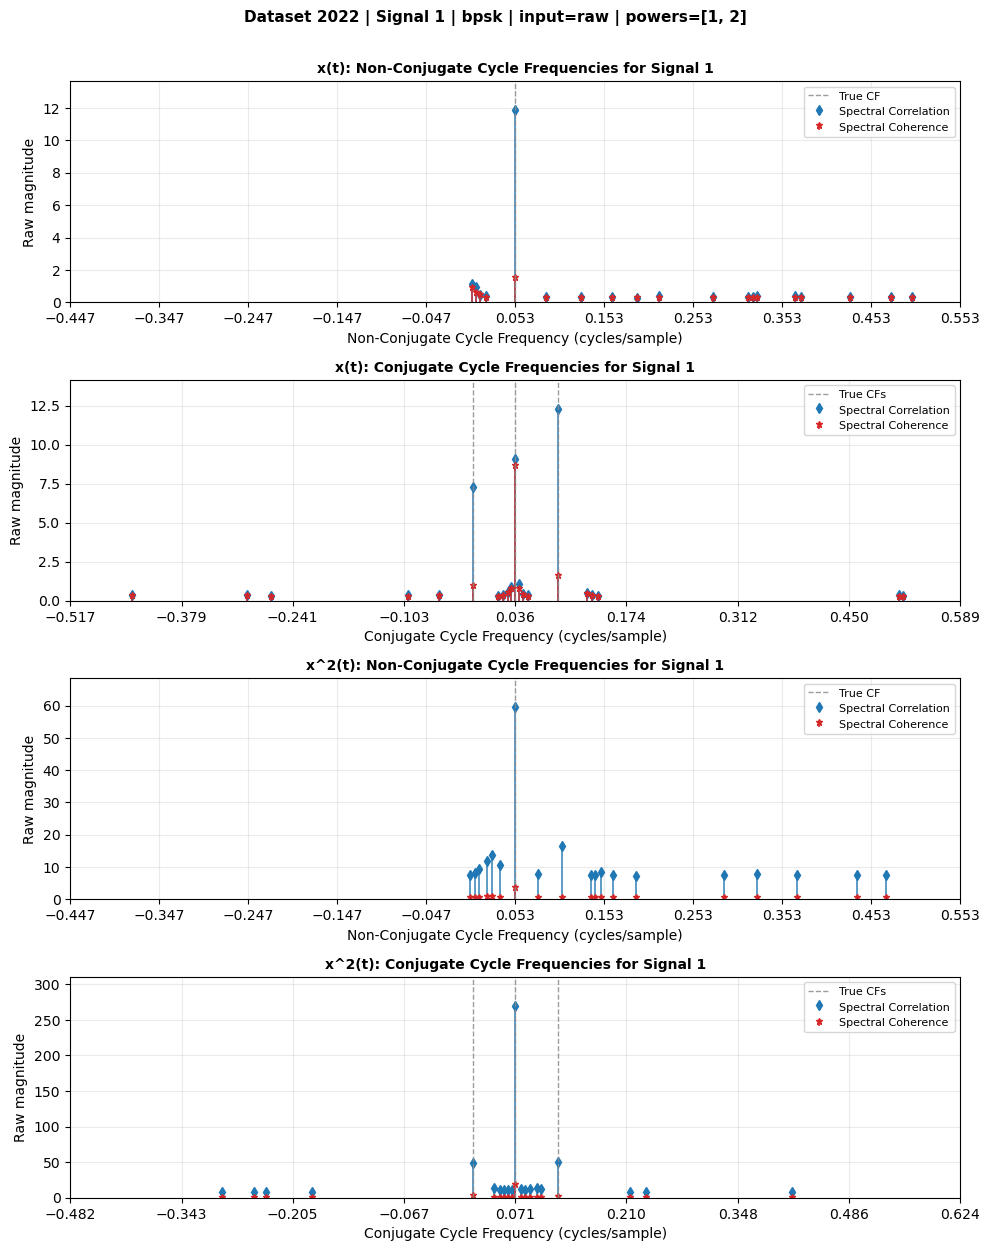

'\nTARGET_SIGNAL_INDICES = [\n    27-2,   # around signal 27 (2018-06-06)\n]\n\nbatch_summary_df, batch_full_results = run_batch_chad_ssca_experiments(\n    dataset_name=TARGET_DATASET_NAME,\n    signal_indices=TARGET_SIGNAL_INDICES,\n    input_mode=SSCA_INPUT_MODE,\n    out_dir=None,\n    save_plots=False,\n    save_summary_csv=False,\n    keep_full_results=False,\n)\n'

In [12]:
# ============================================================
# Chad-style SSCA with:
#   1) principal-domain filtering
#   2) coherence-threshold CF detection
#   3) true CF binning / unique-CF detector
#   4) final user settings:
#        dataset = "2018" or "2022"
#        signal_index = ...
#        input_mode = "boi" or "raw"
#
# Requirement:
#   Run your BOI Step 1-3 code first, because this cell reuses:
#     set_dataset()
#     get_truth_params()
#     global_to_path()
#     tim_to_complex_iq_32768()
#     fixed_resolution_boi()
#     select_boi()
#     prepare_boi_for_stepB()
#     extract_shift_no_resample()
#     FS_IN, DELTA_F0, THRESHOLD_DB, BOI_GUARD_BINS, SAMPLES_PER_SIG, EPS
# ============================================================

import contextlib
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
try:
    from scipy.signal.windows import chebwin
except Exception:
    chebwin = None
import os
import gc
import traceback
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Utility functions
# ============================================================

def normalize_power_local(x, eps=1e-12):
    x = np.asarray(x, dtype=np.complex128)
    return x / np.sqrt(np.mean(np.abs(x) ** 2) + eps)


def make_cheb_window_ssca(Np, atten_db=80):
    if chebwin is not None:
        w = chebwin(Np, at=atten_db, sym=False)
    else:
        w = np.hamming(Np)

    w = np.asarray(w, dtype=np.float64)
    w = w / np.sqrt(np.mean(w ** 2))
    return w


def wrap_freq_ssca(f, fs=1.0):
    return ((f + fs / 2) % fs) - fs / 2


def estimate_psd_welch_ssca(x, fs=1.0, nfft=256, hop=None, eps=1e-15):
    x = np.asarray(x, dtype=np.complex128).ravel()

    if hop is None:
        hop = nfft // 2

    if len(x) < nfft:
        xx = np.zeros(nfft, dtype=np.complex128)
        xx[:len(x)] = x
        x = xx

    w = np.hanning(nfft)
    w_power = np.sum(w ** 2) + eps

    starts = np.arange(0, len(x) - nfft + 1, hop)
    if len(starts) == 0:
        starts = np.array([0])

    P = np.zeros(nfft, dtype=np.float64)

    for s in starts:
        seg = x[s:s + nfft]
        X = np.fft.fftshift(np.fft.fft(seg * w, n=nfft))
        P += np.abs(X) ** 2 / w_power

    P /= len(starts)
    P = np.maximum(P, eps)

    f = np.fft.fftshift(np.fft.fftfreq(nfft, d=1.0 / fs))
    return f, P


def interp_psd_periodic_ssca(f_query, f_psd, Pxx, fs=1.0, eps=1e-15):
    fq = wrap_freq_ssca(f_query, fs)

    order = np.argsort(f_psd)
    fp = f_psd[order]
    pp = Pxx[order]

    fp_ext = np.concatenate([fp - fs, fp, fp + fs])
    pp_ext = np.concatenate([pp, pp, pp])

    out = np.interp(fq.ravel(), fp_ext, pp_ext)
    return np.maximum(out.reshape(f_query.shape), eps)

# ============================================================
# 1.1 Torch / CUDA helpers
# ============================================================

def get_torch_device(preferred="cuda:1"):
    """
    Return torch device.
    If preferred GPU is unavailable, fall back gracefully.
    """
    if torch.cuda.is_available():
        try:
            dev = torch.device(preferred)
            # test allocation
            _ = torch.empty(1, device=dev)
            return dev
        except Exception:
            return torch.device("cuda:0")
    return torch.device("cpu")


def to_numpy_from_torch(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def chad_style_ssca_fixedN_backend(
    x,
    fs=1.0,
    N=32768,
    Np=64,
    branch="nonconj",
    cheb_atten_db=80,
    psd_nfft=512,
    enable_input_power_norm=True,
    backend="numpy",
    torch_device="cuda:1",
):
    """
    Wrapper:
      backend="numpy" -> existing NumPy SSCA
      backend="torch" -> torch.fft SSCA on GPU/CPU

    Returns:
      S, C, f, alpha, N
    """
    backend = str(backend).lower()

    if backend == "numpy":
        return chad_style_ssca_fixedN(
            x=x,
            fs=fs,
            N=N,
            Np=Np,
            branch=branch,
            cheb_atten_db=cheb_atten_db,
            psd_nfft=psd_nfft,
            enable_input_power_norm=enable_input_power_norm,
        )

    if backend != "torch":
        raise ValueError("backend must be 'numpy' or 'torch'.")

    # ------------------------------------------------------------
    # Torch / CUDA path
    # ------------------------------------------------------------
    dev = get_torch_device(torch_device)

    x_np = np.asarray(x, dtype=np.complex64).ravel()

    if enable_input_power_norm:
        x_np = normalize_power_local(x_np).astype(np.complex64)

    needed = N + Np
    if len(x_np) < needed:
        x_work = np.zeros(needed, dtype=np.complex64)
        x_work[:len(x_np)] = x_np
    else:
        x_work = x_np[:needed].copy()

    # channelizer window on CPU first
    w_np = make_cheb_window_ssca(Np, atten_db=cheb_atten_db).astype(np.float32)

    # move to torch
    x_t = torch.from_numpy(x_work).to(dev)
    w_t = torch.from_numpy(w_np).to(dev)

    # L=1 sliding windows: [N, Np]
    Xwin = x_t.unfold(dimension=0, size=Np, step=1)[:N, :]
    Xwin = Xwin * w_t[None, :]

    # First FFT / channelizer
    XF = torch.fft.fftshift(torch.fft.fft(Xwin, n=Np, dim=1), dim=1)

    # Down-conversion phase correction
    n = torch.arange(N, device=dev, dtype=torch.float32)[:, None]
    j_shifted = torch.arange(Np, device=dev, dtype=torch.float32)
    j_unshifted = (j_shifted + Np // 2) % Np
    phase = torch.exp(-1j * 2.0 * np.pi * n * j_unshifted[None, :] / float(Np))
    XT = XF * phase

    # Center sample of each short window
    idx_center = torch.arange(N, device=dev) + Np // 2
    x_center = x_t[idx_center]

    if branch == "nonconj":
        CDP = XT * torch.conj(x_center)[:, None]
    elif branch == "conj":
        CDP = XT * x_center[:, None]
    else:
        raise ValueError("branch must be 'nonconj' or 'conj'.")

    # Strip FFT over time
    S_t = torch.fft.fftshift(torch.fft.fft(CDP, n=N, dim=0), dim=0) / float(N)

    # q and channel center k
    q_norm = torch.fft.fftshift(torch.fft.fftfreq(N, d=1.0, device=dev))
    k_norm = torch.fft.fftshift(torch.fft.fftfreq(Np, d=1.0, device=dev))

    q = q_norm[:, None]
    k = k_norm[None, :]

    alpha_t = (k + q) * fs
    f_t = 0.5 * (k - q) * fs

    # move results back to CPU numpy for coherence calculation
    S = to_numpy_from_torch(S_t)
    alpha = to_numpy_from_torch(alpha_t)
    f = to_numpy_from_torch(f_t)

    # PSD for coherence denominator (CPU side, reusing existing code)
    psd_nfft_eff = int(min(psd_nfft, N))
    f_psd, Pxx = estimate_psd_welch_ssca(
        x_work[:N],
        fs=fs,
        nfft=psd_nfft_eff,
        hop=max(1, psd_nfft_eff // 2),
    )

    C = compute_coherence_ssca(
        S,
        f,
        alpha,
        f_psd,
        Pxx,
        branch=branch,
        fs=fs,
    )

    # optional sync
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)

    return S, C, f, alpha, N
def compute_coherence_ssca(S, f, alpha, f_psd, Pxx, branch, fs=1.0, eps=1e-15):
    """
    Spectral coherence normalization.

    nonconj:
        C_x^alpha(f) = S_x^alpha(f) /
                       sqrt(P(f+alpha/2) P(f-alpha/2))

    conj:
        C_x*^alpha(f) = S_x*^alpha(f) /
                        sqrt(P(f+alpha/2) P(alpha/2-f))
    """
    p1 = interp_psd_periodic_ssca(f + alpha / 2, f_psd, Pxx, fs=fs, eps=eps)

    if branch == "nonconj":
        p2 = interp_psd_periodic_ssca(f - alpha / 2, f_psd, Pxx, fs=fs, eps=eps)
    elif branch == "conj":
        p2 = interp_psd_periodic_ssca(alpha / 2 - f, f_psd, Pxx, fs=fs, eps=eps)
    else:
        raise ValueError("branch must be 'nonconj' or 'conj'.")

    return S / np.sqrt(np.maximum(p1 * p2, eps))


def chad_scale_to_target(x, target_max, eps=1e-15):
    """
    Display-only scaling:
        x_plot = x / max(|x|) * target_max

    This preserves CF locations but not absolute magnitudes.
    """
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return x

    m = np.max(np.abs(x))
    if m <= eps:
        return x

    return x / m * target_max




# ============================================================
# 2. SSCA core
# ============================================================

def chad_style_ssca_fixedN(
    x,
    fs=1.0,
    N=32768,
    Np=64,
    branch="nonconj",
    cheb_atten_db=80,
    psd_nfft=512,
    enable_input_power_norm=True,
):
    """
    Dense L=1 SSCA-like estimator.

    Output:
      S     : spectral correlation estimate table
      C     : spectral coherence estimate table
      f     : spectral-frequency table
      alpha : cycle-frequency table
      N     : strip FFT length

    Mapping used:
      alpha = f_k + q
      f     = 0.5 * (f_k - q)

    with normalized fs included.
    """
    x = np.asarray(x, dtype=np.complex128).ravel()

    if enable_input_power_norm:
        x = normalize_power_local(x)

    needed = N + Np

    if len(x) < needed:
        x_work = np.zeros(needed, dtype=np.complex128)
        x_work[:len(x)] = x
    else:
        x_work = x[:needed].copy()

    # L=1 sliding windows: [N, Np]
    stride = x_work.strides[0]
    Xwin_view = np.lib.stride_tricks.as_strided(
        x_work,
        shape=(N, Np),
        strides=(stride, stride),
        writeable=False,
    )

    # Channelizer window
    w = make_cheb_window_ssca(Np, atten_db=cheb_atten_db)
    Xwin = Xwin_view * w[None, :]

    # First FFT / channelizer
    XF = np.fft.fftshift(np.fft.fft(Xwin, n=Np, axis=1), axes=1)

    # Down-conversion phase correction
    n = np.arange(N)[:, None]
    j_shifted = np.arange(Np)
    j_unshifted = (j_shifted + Np // 2) % Np
    phase = np.exp(-1j * 2 * np.pi * n * j_unshifted[None, :] / Np)
    XT = XF * phase

    # Center sample of each short window
    x_center = x_work[np.arange(N) + Np // 2]

    if branch == "nonconj":
        CDP = XT * np.conj(x_center)[:, None]
    elif branch == "conj":
        CDP = XT * x_center[:, None]
    else:
        raise ValueError("branch must be 'nonconj' or 'conj'.")

    # Strip FFT over time
    S = np.fft.fftshift(np.fft.fft(CDP, n=N, axis=0), axes=0) / N

    # q and channel center k
    q_norm = np.fft.fftshift(np.fft.fftfreq(N, d=1.0))
    k_norm = np.fft.fftshift(np.fft.fftfreq(Np, d=1.0))

    q = q_norm[:, None]
    k = k_norm[None, :]

    alpha = (k + q) * fs
    f = 0.5 * (k - q) * fs

    # PSD for coherence denominator
    psd_nfft_eff = int(min(psd_nfft, N))

    f_psd, Pxx = estimate_psd_welch_ssca(
        x_work[:N],
        fs=fs,
        nfft=psd_nfft_eff,
        hop=max(1, psd_nfft_eff // 2),
    )

    C = compute_coherence_ssca(
        S,
        f,
        alpha,
        f_psd,
        Pxx,
        branch=branch,
        fs=fs,
    )

    return S, C, f, alpha, N


# ============================================================
# 3. Principal-domain filtering + unique-CF detector
# ============================================================

def principal_domain_mask_ssca(f, alpha, fs=1.0, margin=0.0):
    """
    Approximate principal domain for SCF/SCD display and CF detection:

        |f| <= fs/2 - |alpha|/2

    This removes duplicated / invalid outer diamond regions.
    """
    f = np.asarray(f, dtype=np.float64)
    alpha = np.asarray(alpha, dtype=np.float64)

    return (
        (np.abs(alpha) <= fs + margin) &
        (np.abs(f) <= (fs / 2.0 - np.abs(alpha) / 2.0 + margin))
    )


def detect_unique_cfs_from_ssca(
    S,
    C,
    f,
    alpha,
    fs=1.0,
    branch="nonconj",
    use_abs_alpha=True,
    coh_threshold=0.08,
    alpha_min=None,
    alpha_max=None,
    apply_principal_domain=True,
    principal_domain_margin=0.0,
    cf_bin_width=0.002,
    cf_merge_tol=0.004,
    min_cluster_points=1,
    max_cfs=20,
    score_mode="coh",
):
    """
    Chad-style unique CF detector:

      1. optional principal-domain filtering
      2. coherence thresholding
      3. alpha-domain coarse binning
      4. keep one strongest point per coarse alpha bin
      5. non-maximum suppression in alpha to produce unique CFs

    Returned rows are sorted by alpha.

    Notes:
      - This is blind with respect to truth labels.
      - It uses only SSCA S/C/f/alpha tables.
      - For nonconj, use_abs_alpha=True is usually convenient.
      - For conj, use_abs_alpha=False keeps signed CFs.
    """
    S_abs = np.abs(S)
    C_abs = np.abs(C)

    if alpha_min is None:
        alpha_min = fs / S.shape[0] if branch == "nonconj" else -fs

    if alpha_max is None:
        alpha_max = fs if use_abs_alpha else fs

    if use_abs_alpha:
        alpha_det = np.abs(alpha)
    else:
        alpha_det = alpha.copy()

    mask = np.isfinite(S_abs) & np.isfinite(C_abs)

    if apply_principal_domain:
        mask &= principal_domain_mask_ssca(
            f=f,
            alpha=alpha,
            fs=fs,
            margin=principal_domain_margin,
        )

    mask &= C_abs >= coh_threshold
    mask &= alpha_det >= alpha_min
    mask &= alpha_det <= alpha_max

    if not np.any(mask):
        return []

    a_vals = alpha_det[mask]
    f_vals = f[mask]
    s_vals = S_abs[mask]
    c_vals = C_abs[mask]

    # Coarse alpha binning.
    # This is the key step that turns many SSCA points into unique CF candidates.
    bin_id = np.rint(a_vals / cf_bin_width).astype(np.int64)
    unique_bins = np.unique(bin_id)

    candidates = []

    for b in unique_bins:
        idx = np.where(bin_id == b)[0]

        if idx.size < min_cluster_points:
            continue

        if score_mode == "scf":
            best_local = idx[np.argmax(s_vals[idx])]
            score = float(s_vals[best_local])
        elif score_mode == "coh":
            best_local = idx[np.argmax(c_vals[idx])]
            score = float(c_vals[best_local])
        elif score_mode == "scf_x_coh":
            score_vals = s_vals[idx] * c_vals[idx]
            best_local = idx[np.argmax(score_vals)]
            score = float(score_vals[np.argmax(score_vals)])
        else:
            raise ValueError("score_mode must be 'coh', 'scf', or 'scf_x_coh'.")

        candidates.append({
            "alpha": float(a_vals[best_local]),
            "f": float(f_vals[best_local]),
            "scf": float(s_vals[best_local]),
            "coh": float(c_vals[best_local]),
            "score": float(score),
            "bin_center": float(b * cf_bin_width),
            "num_points": int(idx.size),
        })

    if len(candidates) == 0:
        return []

    # Non-maximum suppression in alpha:
    # sort by score descending, then suppress nearby CFs.
    candidates_sorted = sorted(candidates, key=lambda d: d["score"], reverse=True)

    selected = []
    for cand in candidates_sorted:
        too_close = False
        for sel in selected:
            if abs(cand["alpha"] - sel["alpha"]) <= cf_merge_tol:
                too_close = True
                break

        if not too_close:
            selected.append(cand)

        if len(selected) >= max_cfs:
            break

    selected = sorted(selected, key=lambda d: d["alpha"])
    return selected


def unique_cfs_to_arrays(unique_cfs):
    if len(unique_cfs) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    alpha = np.array([d["alpha"] for d in unique_cfs], dtype=np.float64)
    scf = np.array([d["scf"] for d in unique_cfs], dtype=np.float64)
    coh = np.array([d["coh"] for d in unique_cfs], dtype=np.float64)
    score = np.array([d["score"] for d in unique_cfs], dtype=np.float64)
    return alpha, scf, coh, score


def print_unique_cf_table(unique_cfs, title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    if len(unique_cfs) == 0:
        print("No unique CFs detected.")
        return

    print(f"{'id':>3s} | {'alpha':>14s} | {'f':>14s} | {'|SCF|':>14s} | {'|COH|':>14s} | {'points':>8s}")
    print("-" * 80)

    for i, d in enumerate(unique_cfs):
        print(
            f"{i:3d} | "
            f"{d['alpha']:14.8e} | "
            f"{d['f']:14.8e} | "
            f"{d['scf']:14.8e} | "
            f"{d['coh']:14.8e} | "
            f"{d['num_points']:8d}"
        )


# ============================================================
# 4. Input preparation: raw or BOI-filtered+shifted
# ============================================================

def load_raw_record_for_ssca(dataset_name, signal_index):
    root_data, label_path, truth_df = set_dataset(dataset_name)
    truth = get_truth_params(truth_df, signal_index)
    tim_path, batch_dir = global_to_path(root_data, signal_index)
    x = tim_to_complex_iq_32768(tim_path)

    return {
        "dataset_name": dataset_name,
        "signal_index": signal_index,
        "truth": truth,
        "input_mode": "raw",
        "x_original": np.asarray(x, dtype=np.complex128),
        "x_processed": np.asarray(x, dtype=np.complex128),
        "fs_processed": 1.0,
        "center_shift_hz": 0.0,
        "center_shift_method": "none_raw_input",
        "tim_path": tim_path,
        "batch_dir": batch_dir,
    }


def load_boi_noresample_record_for_ssca(dataset_name, signal_index):
    root_data, label_path, truth_df = set_dataset(dataset_name)
    truth = get_truth_params(truth_df, signal_index)
    tim_path, batch_dir = global_to_path(root_data, signal_index)
    x = tim_to_complex_iq_32768(tim_path)

    boi_result = fixed_resolution_boi(
        x=x,
        fs=FS_IN,
        delta_f0=DELTA_F0,
        threshold_db=THRESHOLD_DB,
        min_width_bins=2,
        keep_weak=True,
    )

    selected_initial = select_boi(boi_result, mode="strongest")

    prepared = prepare_boi_for_stepB(
        x_node=x,
        boi_result=boi_result,
        selected_initial=selected_initial,
        fs_node=FS_IN,
    )

    selected_for_power = prepared["selected_refined"]
    selected_for_filter = prepared["selected_filter"]
    power_report = prepared["power_report"]

    stepB_noresample = extract_shift_no_resample(
        x=x,
        boi=selected_for_filter,
        fs=FS_IN,
        guard_bins=BOI_GUARD_BINS,
    )

    x_processed = np.asarray(stepB_noresample["x_noresample"], dtype=np.complex128)
    fs_processed = float(stepB_noresample["fs_out"])

    if x_processed.size != SAMPLES_PER_SIG:
        raise RuntimeError(
            f"signal_{signal_index}: expected {SAMPLES_PER_SIG} samples after BOI no-resample, "
            f"got {x_processed.size}"
        )

    if abs(fs_processed - 1.0) > 1e-12:
        raise RuntimeError(
            f"signal_{signal_index}: expected fs_processed=1.0, got {fs_processed}"
        )

    return {
        "dataset_name": dataset_name,
        "signal_index": signal_index,
        "truth": truth,
        "input_mode": "boi",
        "x_original": np.asarray(x, dtype=np.complex128),
        "x_processed": x_processed,
        "fs_processed": fs_processed,
        "center_shift_hz": float(selected_for_power["f_center"]),
        "center_shift_method": selected_for_power.get("f_center_method", "boi_center"),
        "tim_path": tim_path,
        "batch_dir": batch_dir,

        "boi_result": boi_result,
        "selected_boi_refined": selected_for_power,
        "selected_boi_filter": selected_for_filter,
        "power_report": power_report,
        "stepB_noresample": stepB_noresample,
    }


def load_record_for_ssca(dataset_name, signal_index, input_mode="boi"):
    input_mode = str(input_mode).lower()

    if input_mode in ["boi", "boi_noresample", "boi_shifted"]:
        return load_boi_noresample_record_for_ssca(dataset_name, signal_index)

    if input_mode in ["raw", "original", "unprocessed"]:
        return load_raw_record_for_ssca(dataset_name, signal_index)

    raise ValueError("input_mode must be 'boi' or 'raw'.")


# ============================================================
# 5. Run SSCA + unique-CF detection
# ============================================================

def run_ssca_and_detect_cfs(
    record,
    ssca_n=32768,
    ssca_np=64,
    ssca_cheb_atten_db=80,
    ssca_psd_nfft=512,
    ssca_coh_threshold=0.08,
    cf_bin_width=0.002,
    cf_merge_tol=0.004,
    max_unique_cfs=20,
    enable_input_power_norm=True,
    ssca_backend="numpy",
    torch_device="cuda:1",
    power_list=(1, 2, 4),
):
    x_proc = np.asarray(record["x_processed"], dtype=np.complex128)
    fs_proc = float(record["fs_processed"])

    # Normalize / validate power list.
    power_list = [int(p) for p in power_list]
    power_list = sorted(list(dict.fromkeys(power_list)))

    if 1 not in power_list:
        raise ValueError("power_list must include 1, because p=1 is the original x(t) branch.")

    out = dict(record)
    out["power_list"] = list(power_list)
    out["power_results"] = {}

    for p in power_list:
        # ========================================================
        # Build powered signal y(t)=x(t)^p
        # ========================================================
        if p == 1:
            y_proc = x_proc
            label = "x"
        else:
            y_proc = x_proc ** p
            label = f"x{p}"

        # ----------------------------
        # y(t) non-conjugate SSCA
        # ----------------------------
        S_nc, C_nc, f_nc, a_nc, N_nc = chad_style_ssca_fixedN_backend(
            y_proc,
            fs=fs_proc,
            N=ssca_n,
            Np=ssca_np,
            branch="nonconj",
            cheb_atten_db=ssca_cheb_atten_db,
            psd_nfft=ssca_psd_nfft,
            enable_input_power_norm=enable_input_power_norm,
            backend=ssca_backend,
            torch_device=torch_device,
        )

        unique_nc = detect_unique_cfs_from_ssca(
            S=S_nc,
            C=C_nc,
            f=f_nc,
            alpha=a_nc,
            fs=fs_proc,
            branch="nonconj",
            use_abs_alpha=True,
            coh_threshold=ssca_coh_threshold,
            alpha_min=fs_proc / N_nc,
            alpha_max=fs_proc,
            apply_principal_domain=True,
            principal_domain_margin=0.0,
            cf_bin_width=cf_bin_width,
            cf_merge_tol=cf_merge_tol,
            min_cluster_points=1,
            max_cfs=max_unique_cfs,
            score_mode="coh",
        )

        # ----------------------------
        # y(t) conjugate SSCA
        # ----------------------------
        S_c, C_c, f_c, a_c, N_c = chad_style_ssca_fixedN_backend(
            y_proc,
            fs=fs_proc,
            N=ssca_n,
            Np=ssca_np,
            branch="conj",
            cheb_atten_db=ssca_cheb_atten_db,
            psd_nfft=ssca_psd_nfft,
            enable_input_power_norm=enable_input_power_norm,
            backend=ssca_backend,
            torch_device=torch_device,
        )

        unique_c = detect_unique_cfs_from_ssca(
            S=S_c,
            C=C_c,
            f=f_c,
            alpha=a_c,
            fs=fs_proc,
            branch="conj",
            use_abs_alpha=False,
            coh_threshold=ssca_coh_threshold,
            alpha_min=-fs_proc,
            alpha_max=+fs_proc,
            apply_principal_domain=True,
            principal_domain_margin=0.0,
            cf_bin_width=cf_bin_width,
            cf_merge_tol=cf_merge_tol,
            min_cluster_points=1,
            max_cfs=max_unique_cfs,
            score_mode="coh",
        )

        out["power_results"][p] = {
            "label": label,
            "y_processed": y_proc,

            "S_nc": S_nc,
            "C_nc": C_nc,
            "f_nc": f_nc,
            "alpha_table_nc": a_nc,
            "N_ssca_nc": N_nc,
            "unique_nc": unique_nc,

            "S_c": S_c,
            "C_c": C_c,
            "f_c": f_c,
            "alpha_table_c": a_c,
            "N_ssca_c": N_c,
            "unique_c": unique_c,
        }

        # ========================================================
        # Backward-compatible flat keys
        # ========================================================
        if p == 1:
            out.update({
                "S_nc": S_nc,
                "C_nc": C_nc,
                "f_nc": f_nc,
                "alpha_table_nc": a_nc,
                "N_ssca_nc": N_nc,
                "unique_nc": unique_nc,

                "S_c": S_c,
                "C_c": C_c,
                "f_c": f_c,
                "alpha_table_c": a_c,
                "N_ssca_c": N_c,
                "unique_c": unique_c,
            })
        else:
            out.update({
                f"x{p}_processed": y_proc,

                f"S_x{p}_nc": S_nc,
                f"C_x{p}_nc": C_nc,
                f"f_x{p}_nc": f_nc,
                f"alpha_table_x{p}_nc": a_nc,
                f"N_ssca_x{p}_nc": N_nc,
                f"unique_x{p}_nc": unique_nc,

                f"S_x{p}_c": S_c,
                f"C_x{p}_c": C_c,
                f"f_x{p}_c": f_c,
                f"alpha_table_x{p}_c": a_c,
                f"N_ssca_x{p}_c": N_c,
                f"unique_x{p}_c": unique_c,
            })

    out["ssca_params"] = {
        "N": int(ssca_n),
        "Np": int(ssca_np),
        "cheb_atten_db": float(ssca_cheb_atten_db),
        "psd_nfft": int(ssca_psd_nfft),
        "coh_threshold": float(ssca_coh_threshold),
        "cf_bin_width": float(cf_bin_width),
        "cf_merge_tol": float(cf_merge_tol),
        "max_unique_cfs": int(max_unique_cfs),
        "enable_input_power_norm": bool(enable_input_power_norm),
        "backend": str(ssca_backend),
        "torch_device": str(torch_device),
        "power_list": list(power_list),
    }

    return out

# ============================================================
# 6. Truth CF guide lines
# ============================================================
def auto_xlim_from_truth_cfs(true_cfs, pad=0.5, hard_clip=None, min_span=0.2):
    """
    Build x-axis range from truth CF guide values.

    Rule:
      xlim = [min(true_cfs)-pad, max(true_cfs)+pad]

    Example:
      true non-conj CFs = [0.4375]
      -> xlim = [-0.0625, 0.9375]

      true conj CFs = [-0.3976, 0.0399, 0.4774]
      -> xlim = [-0.8976, 0.9774]

    hard_clip:
      None: no clipping
      tuple/list: clip to [hard_clip[0], hard_clip[1]]
    """
    true_cfs = np.asarray(true_cfs, dtype=np.float64)

    if true_cfs.size == 0 or not np.any(np.isfinite(true_cfs)):
        return (-0.5, 0.5)

    vals = true_cfs[np.isfinite(true_cfs)]

    lo = float(np.min(vals) - pad)
    hi = float(np.max(vals) + pad)

    if hi - lo < min_span:
        center = 0.5 * (lo + hi)
        lo = center - 0.5 * min_span
        hi = center + 0.5 * min_span

    if hard_clip is not None:
        lo = max(float(hard_clip[0]), lo)
        hi = min(float(hard_clip[1]), hi)

    return (lo, hi)

def get_truth_second_order_cfs_for_plot(record, kmax=1):
    """
    Returns true CF guides for plotting.

    Non-conjugate:
        alpha = k * Rs

    Conjugate:
        raw input:
            alpha = 2*f0 + k*Rs

        BOI-shifted input:
            alpha = 2*(f0 - f_center_hat) + k*Rs
    """
    truth = record["truth"]

    Rs = float(truth["symbol_rate"])
    f0 = float(truth["carrier_offset_label"])

    input_mode = record.get("input_mode", "boi")
    center_shift = float(record.get("center_shift_hz", 0.0))

    if input_mode == "boi":
        f_res = f0 - center_shift
    else:
        f_res = f0

    true_nc = np.array([k * Rs for k in range(1, kmax + 1)], dtype=np.float64)
    true_c = np.array([2.0 * f_res + k * Rs for k in range(-kmax, kmax + 1)], dtype=np.float64)

    return true_nc, true_c

def get_truth_second_order_cfs_for_plot_power(record, power=1, kmax=1):
    """
    True second-order CF guides for y(t) = x(t)^power.

    Original signal:
        x(t) = s(t) exp(j 2π f_eff t)

    Powered signal:
        y(t) = x(t)^power
             = s(t)^power exp(j 2π (power * f_eff) t)

    Therefore, for y(t):

      second-order non-conjugate CF:
          alpha = k * Rs

      second-order conjugate CF:
          alpha = 2 * power * f_eff + k * Rs

    Examples:
      power=1:
          y=x
          conj CF = 2 f_eff + k Rs

      power=2:
          y=x^2
          conj CF = 4 f_eff + k Rs

      power=4:
          y=x^4
          conj CF = 8 f_eff + k Rs

    raw input:
        f_eff = f0

    BOI-shifted input:
        f_eff = f0 - f_center_hat
    """
    truth = record["truth"]

    Rs = float(truth["symbol_rate"])
    f0 = float(truth["carrier_offset_label"])

    input_mode = record.get("input_mode", "boi")
    center_shift = float(record.get("center_shift_hz", 0.0))

    if input_mode == "boi":
        f_eff = f0 - center_shift
    else:
        f_eff = f0

    true_nc = np.array(
        [k * Rs for k in range(1, kmax + 1)],
        dtype=np.float64,
    )

    true_c = np.array(
        [2.0 * float(power) * f_eff + k * Rs for k in range(-kmax, kmax + 1)],
        dtype=np.float64,
    )

    return true_nc, true_c


def get_truth_second_order_cfs_for_plot_x2(record, kmax=1):
    """
    Backward-compatible alias for y(t)=x(t)^2.
    """
    return get_truth_second_order_cfs_for_plot_power(record, power=2, kmax=kmax)

# ============================================================
# 7. Plot unique CFs
# ============================================================

def chad_stem(ax, x, y, linefmt, markerfmt, label):
    markerline, stemlines, baseline = ax.stem(
        x,
        y,
        linefmt=linefmt,
        markerfmt=markerfmt,
        basefmt=" ",
        label=label,
    )
    plt.setp(markerline, markersize=5)
    plt.setp(stemlines, linewidth=1.2, alpha=0.85)
    return markerline, stemlines, baseline

def power_label_for_plot(p):
    if int(p) == 1:
        return "x(t)"
    return f"x^{int(p)}(t)"


def plot_unique_cfs_chad_style(
    result,
    xlim_by_power=None,
    kmax_true=1,
):
    sig_idx = result["signal_index"]
    sig_type = result["truth"]["signal_type"]
    dataset_name = result["dataset_name"]
    input_mode = result["input_mode"]

    power_list = result.get("power_list", [1, 2])
    power_list = [int(p) for p in power_list]

    if xlim_by_power is None:
        xlim_by_power = {}

    nrows = 2 * len(power_list)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=1,
        figsize=(10.0, 3.1 * nrows),
        sharex=False,
    )

    if nrows == 1:
        axes = [axes]

    row = 0

    for p in power_list:
        p_result = result["power_results"][p]
        label = power_label_for_plot(p)

        # --------------------------------------------------------
        # Fetch unique CF arrays
        # --------------------------------------------------------
        alpha_nc, scf_nc, coh_nc, _ = unique_cfs_to_arrays(p_result.get("unique_nc", []))
        alpha_c, scf_c, coh_c, _ = unique_cfs_to_arrays(p_result.get("unique_c", []))

        scf_nc_plot = np.asarray(scf_nc, dtype=np.float64)
        coh_nc_plot = np.asarray(coh_nc, dtype=np.float64)

        scf_c_plot = np.asarray(scf_c, dtype=np.float64)
        coh_c_plot = np.asarray(coh_c, dtype=np.float64)

        true_nc, true_c = get_truth_second_order_cfs_for_plot_power(
            result,
            power=p,
            kmax=kmax_true,
        )

        xlim_nc = xlim_by_power.get((p, "nonconj"), auto_xlim_from_truth_cfs(true_nc, pad=0.5))
        xlim_c = xlim_by_power.get((p, "conj"), auto_xlim_from_truth_cfs(true_c, pad=0.5))

        # ========================================================
        # non-conjugate plot
        # ========================================================
        ax = axes[row]
        row += 1

        if alpha_nc.size > 0:
            chad_stem(
                ax,
                alpha_nc,
                scf_nc_plot,
                linefmt="C0-",
                markerfmt="C0d",
                label="Spectral Correlation",
            )
            chad_stem(
                ax,
                alpha_nc,
                coh_nc_plot,
                linefmt="C3-",
                markerfmt="C3*",
                label="Spectral Coherence",
            )
        else:
            ax.text(
                0.5,
                0.5,
                "No unique CFs detected",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )

        first = True
        for a in true_nc:
            if xlim_nc[0] <= a <= xlim_nc[1]:
                ax.axvline(
                    a,
                    color="0.55",
                    linestyle="--",
                    linewidth=1.0,
                    alpha=0.85,
                    label="True CF" if first else None,
                )
                first = False

        ax.set_xlim(*xlim_nc)

        ymax = max(
            np.max(scf_nc_plot) if scf_nc_plot.size else 0.0,
            np.max(coh_nc_plot) if coh_nc_plot.size else 0.0,
            1e-12,
        )

        ax.set_ylim(0.0, 1.15 * ymax)
        ax.set_xticks(np.linspace(xlim_nc[0], xlim_nc[1], 11))
        ax.set_title(
            f"{label}: Non-Conjugate Cycle Frequencies for Signal {sig_idx}",
            fontsize=10,
            fontweight="bold",
        )
        ax.set_xlabel("Non-Conjugate Cycle Frequency (cycles/sample)")
        ax.set_ylabel("Raw magnitude")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper right", fontsize=8)

        # ========================================================
        # conjugate plot
        # ========================================================
        ax = axes[row]
        row += 1

        if alpha_c.size > 0:
            chad_stem(
                ax,
                alpha_c,
                scf_c_plot,
                linefmt="C0-",
                markerfmt="C0d",
                label="Spectral Correlation",
            )
            chad_stem(
                ax,
                alpha_c,
                coh_c_plot,
                linefmt="C3-",
                markerfmt="C3*",
                label="Spectral Coherence",
            )
        else:
            ax.text(
                0.5,
                0.5,
                "No unique CFs detected",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )

        first = True
        for a in true_c:
            if xlim_c[0] <= a <= xlim_c[1]:
                ax.axvline(
                    a,
                    color="0.55",
                    linestyle="--",
                    linewidth=1.0,
                    alpha=0.85,
                    label="True CFs" if first else None,
                )
                first = False

        ax.set_xlim(*xlim_c)

        ymax = max(
            np.max(scf_c_plot) if scf_c_plot.size else 0.0,
            np.max(coh_c_plot) if coh_c_plot.size else 0.0,
            1e-12,
        )

        ax.set_ylim(0.0, 1.15 * ymax)
        ax.set_xticks(np.linspace(xlim_c[0], xlim_c[1], 9))
        ax.set_title(
            f"{label}: Conjugate Cycle Frequencies for Signal {sig_idx}",
            fontsize=10,
            fontweight="bold",
        )
        ax.set_xlabel("Conjugate Cycle Frequency (cycles/sample)")
        ax.set_ylabel("Raw magnitude")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper right", fontsize=8)

    plt.suptitle(
        f"Dataset {dataset_name} | Signal {sig_idx} | {sig_type} | input={input_mode} | powers={power_list}",
        y=1.005,
        fontsize=11,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
# ============================================================
# 8. One-call experiment runner
# ============================================================
def run_one_chad_ssca_experiment_silent(
    dataset_name,
    signal_index,
    input_mode,
    out_dir=None,
    save_plot=True,
    close_plot=True,
):
    """
    Batch wrapper for one signal.

    It reuses your existing run_one_chad_ssca_experiment().
    Main difference:
      - suppresses long console output
      - optionally saves current figure
      - returns a compact summary row + full result
    """
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            result = run_one_chad_ssca_experiment(
                dataset_name=dataset_name,
                signal_index=signal_index,
                input_mode=input_mode,
                ssca_n=TARGET_SSCA_N,
                ssca_np=TARGET_SSCA_NP,
                ssca_cheb_atten_db=80,
                ssca_psd_nfft=512,
                ssca_coh_threshold=TARGET_COH_THRESHOLD,
                cf_bin_width=TARGET_CF_BIN_WIDTH,
                cf_merge_tol=TARGET_CF_MERGE_TOL,
                max_unique_cfs=TARGET_MAX_UNIQUE_CFS,
                enable_input_power_norm=TARGET_ENABLE_INPUT_POWER_NORM,
                show_plot=True,
                ssca_backend=TARGET_SSCA_BACKEND,
                torch_device=TARGET_TORCH_DEVICE,
                power_list=TARGET_POWER_LIST,
            )

        truth = result["truth"]

        # Save figure if requested.
        fig_path = None
        if save_plot and out_dir is not None:
            os.makedirs(out_dir, exist_ok=True)

            sig_type = str(truth["signal_type"])
            fig_path = os.path.join(
                out_dir,
                f"{dataset_name}_signal_{signal_index:06d}_{sig_type}_{input_mode}.jpg"
            )

            plt.savefig(fig_path, dpi=180, bbox_inches="tight")

        if close_plot:
            plt.close("all")

        # Compact maxima helper.
        def max_scf(unique_list):
            return max([d["scf"] for d in unique_list], default=np.nan)

        def max_coh(unique_list):
            return max([d["coh"] for d in unique_list], default=np.nan)

        def strongest_alpha(unique_list, key="scf"):
            if len(unique_list) == 0:
                return np.nan
            return max(unique_list, key=lambda d: d[key])["alpha"]

        true_nc, true_c = get_truth_second_order_cfs_for_plot(result, kmax=1)
        true_x2_nc, true_x2_c = get_truth_second_order_cfs_for_plot_x2(result, kmax=1)
        true_x4_nc, true_x4_c = get_truth_second_order_cfs_for_plot_power(result, power=4, kmax=1)

        row = {
            "dataset": dataset_name,
            "signal_index": signal_index,
            "signal_type": truth["signal_type"],
            "input_mode": input_mode,
            "truth_Rs": float(truth["symbol_rate"]),
            "truth_CFO": float(truth["carrier_offset_label"]),
            "center_shift_hz": float(result.get("center_shift_hz", 0.0)),
            "fs_processed": float(result["fs_processed"]),

            "true_nc_0": float(true_nc[0]) if len(true_nc) else np.nan,
            "true_c_values": ",".join([f"{v:.10e}" for v in true_c]),
            "true_x2_nc_0": float(true_x2_nc[0]) if len(true_x2_nc) else np.nan,
            "true_x2_c_values": ",".join([f"{v:.10e}" for v in true_x2_c]),

            "num_nc": len(result.get("unique_nc", [])),
            "num_c": len(result.get("unique_c", [])),
            "num_x2_nc": len(result.get("unique_x2_nc", [])),
            "num_x2_c": len(result.get("unique_x2_c", [])),

            "max_nc_scf": max_scf(result.get("unique_nc", [])),
            "max_c_scf": max_scf(result.get("unique_c", [])),
            "max_x2_nc_scf": max_scf(result.get("unique_x2_nc", [])),
            "max_x2_c_scf": max_scf(result.get("unique_x2_c", [])),

            "max_nc_coh": max_coh(result.get("unique_nc", [])),
            "max_c_coh": max_coh(result.get("unique_c", [])),
            "max_x2_nc_coh": max_coh(result.get("unique_x2_nc", [])),
            "max_x2_c_coh": max_coh(result.get("unique_x2_c", [])),

            "strongest_nc_alpha_by_scf": strongest_alpha(result.get("unique_nc", []), key="scf"),
            "strongest_c_alpha_by_scf": strongest_alpha(result.get("unique_c", []), key="scf"),
            "strongest_x2_nc_alpha_by_scf": strongest_alpha(result.get("unique_x2_nc", []), key="scf"),
            "strongest_x2_c_alpha_by_scf": strongest_alpha(result.get("unique_x2_c", []), key="scf"),

            "true_x4_nc_0": float(true_x4_nc[0]) if len(true_x4_nc) else np.nan,
            "true_x4_c_values": ",".join([f"{v:.10e}" for v in true_x4_c]),

            "num_x4_nc": len(result.get("unique_x4_nc", [])),
            "num_x4_c": len(result.get("unique_x4_c", [])),

            "max_x4_nc_scf": max_scf(result.get("unique_x4_nc", [])),
            "max_x4_c_scf": max_scf(result.get("unique_x4_c", [])),

            "max_x4_nc_coh": max_coh(result.get("unique_x4_nc", [])),
            "max_x4_c_coh": max_coh(result.get("unique_x4_c", [])),

            "strongest_x4_nc_alpha_by_scf": strongest_alpha(result.get("unique_x4_nc", []), key="scf"),
            "strongest_x4_c_alpha_by_scf": strongest_alpha(result.get("unique_x4_c", []), key="scf"),

            "fig_path": fig_path,
            "status": "ok",
            "error": "",
        }

        return row, result

    except Exception as e:
        if close_plot:
            plt.close("all")

        row = {
            "dataset": dataset_name,
            "signal_index": signal_index,
            "signal_type": "",
            "input_mode": input_mode,
            "status": "error",
            "error": repr(e),
        }

        print(f"[ERROR] dataset={dataset_name} signal={signal_index}: {repr(e)}")
        traceback.print_exc()

        return row, None


def run_batch_chad_ssca_experiments(
    dataset_name,
    signal_indices,
    input_mode="raw",
    out_dir=None,
    save_plots=False,
    save_summary_csv=False,
    keep_full_results=False,
    clear_cuda_each_signal=True,
):
    """
    Batch process multiple signal indices.

    Modes:
      save_plots=False       -> do not save jpg figures
      save_summary_csv=False -> do not save CSV summary
      keep_full_results=False -> do not keep large SSCA matrices in memory

    Output:
      summary_df
      full_results, optional dictionary {signal_index: result}
    """
    if save_plots or save_summary_csv:
        if out_dir is None:
            out_dir = "./ssca_batch_outputs"
        os.makedirs(out_dir, exist_ok=True)

    rows = []
    full_results = {} if keep_full_results else None

    signal_indices = list(signal_indices)
    total = len(signal_indices)

    print("============================================================")
    print("Batch Chad-style SSCA processing")
    print("============================================================")
    print(f"dataset_name      : {dataset_name}")
    print(f"input_mode        : {input_mode}")
    print(f"num_signals       : {total}")
    print(f"save_plots        : {save_plots}")
    print(f"save_summary_csv  : {save_summary_csv}")
    print(f"out_dir           : {out_dir}")
    print(f"backend           : {TARGET_SSCA_BACKEND}")
    print(f"torch_device      : {TARGET_TORCH_DEVICE}")
    print(f"power_list        : {TARGET_POWER_LIST}")

    for i, sig_idx in enumerate(signal_indices, start=1):
        print(f"\n[{i:03d}/{total:03d}] Processing signal_index={sig_idx} ...")

        row, result = run_one_chad_ssca_experiment_silent(
            dataset_name=dataset_name,
            signal_index=int(sig_idx),
            input_mode=input_mode,
            out_dir=out_dir,
            save_plot=save_plots,
            close_plot=not save_plots,   # if not saving, allow notebook output
        )

        rows.append(row)

        if keep_full_results and result is not None:
            full_results[int(sig_idx)] = result

        if not keep_full_results:
            del result

        gc.collect()

        if clear_cuda_each_signal and torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(
            f"status={row.get('status')} | "
            f"type={row.get('signal_type', '')} | "
            f"max_nc_scf={row.get('max_nc_scf', np.nan)} | "
            f"max_x2_c_scf={row.get('max_x2_c_scf', np.nan)} | "
            f"max_x4_c_scf={row.get('max_x4_c_scf', np.nan)}"
        )

    summary_df = pd.DataFrame(rows)

    if save_summary_csv:
        summary_csv = os.path.join(out_dir, f"{dataset_name}_{input_mode}_batch_summary.csv")
        summary_df.to_csv(summary_csv, index=False)
        print("\n============================================================")
        print("Batch finished")
        print("============================================================")
        print(f"summary_csv: {summary_csv}")
    else:
        print("\n============================================================")
        print("Batch finished")
        print("No files saved.")
        print("============================================================")

    return summary_df, full_results
def run_one_chad_ssca_experiment(
    dataset_name="2018",
    signal_index=1,
    input_mode="boi",
    ssca_n=32768,
    ssca_np=64,
    ssca_cheb_atten_db=80,
    ssca_psd_nfft=512,
    ssca_coh_threshold=0.08,
    cf_bin_width=0.002,
    cf_merge_tol=0.004,
    max_unique_cfs=20,
    enable_input_power_norm=True,
    show_plot=True,
    ssca_backend="numpy",
    torch_device="cuda:1",
    power_list=(1, 2, 4),
):
    print("============================================================")
    print("Run Chad-style SSCA experiment")
    print("============================================================")
    print(f"dataset_name        : {dataset_name}")
    print(f"signal_index        : {signal_index}")
    print(f"input_mode          : {input_mode}  # 'boi' or 'raw'")
    print(f"SSCA_N              : {ssca_n}")
    print(f"SSCA_NP             : {ssca_np}")
    print(f"coh_threshold       : {ssca_coh_threshold}")
    print(f"cf_bin_width        : {cf_bin_width}")
    print(f"cf_merge_tol        : {cf_merge_tol}")
    print(f"input_power_norm    : {enable_input_power_norm}")
    print(f"ssca_backend        : {ssca_backend}")
    print(f"torch_device        : {torch_device}")
    print(f"power_list          : {list(power_list)}")

    with contextlib.redirect_stdout(io.StringIO()):
        record = load_record_for_ssca(
            dataset_name=dataset_name,
            signal_index=signal_index,
            input_mode=input_mode,
        )

    result = run_ssca_and_detect_cfs(
        record=record,
        ssca_n=ssca_n,
        ssca_np=ssca_np,
        ssca_cheb_atten_db=ssca_cheb_atten_db,
        ssca_psd_nfft=ssca_psd_nfft,
        ssca_coh_threshold=ssca_coh_threshold,
        cf_bin_width=cf_bin_width,
        cf_merge_tol=cf_merge_tol,
        max_unique_cfs=max_unique_cfs,
        enable_input_power_norm=enable_input_power_norm,
        ssca_backend=ssca_backend,
        torch_device=torch_device,
        power_list=power_list,
    )

    truth = result["truth"]
    print("\n============================================================")
    print("Signal truth / preprocessing")
    print("============================================================")
    print(f"type                : {truth['signal_type']}")
    print(f"truth Rs            : {truth['symbol_rate']:.10e}")
    print(f"truth CFO           : {truth['carrier_offset_label']:.10e}")
    print(f"input mode          : {result['input_mode']}")
    print(f"center shift        : {result.get('center_shift_hz', 0.0):+.10e}")
    print(f"center shift method : {result.get('center_shift_method', 'none')}")
    print(f"x_processed shape   : {result['x_processed'].shape}")
    print(f"fs_processed        : {result['fs_processed']}")

    print_unique_cf_table(
        result["unique_nc"],
        title="Detected unique NON-CONJUGATE CFs after principal-domain filtering + CF binning"
    )

    print_unique_cf_table(
        result["unique_c"],
        title="Detected unique CONJUGATE CFs after principal-domain filtering + CF binning"
    )

    true_nc, true_c = get_truth_second_order_cfs_for_plot(result, kmax=1)

    print("\n============================================================")
    print("Truth CF guides used only for plotting/reference")
    print("============================================================")
    print(f"true non-conj CFs : {true_nc}")
    print(f"true conj CFs     : {true_c}")

    # Powered-signal branch summaries
    print("\n============================================================")
    print("Powered-signal SSCA summaries")
    print("============================================================")

    for p in result.get("power_list", [1]):
        p = int(p)
        label = power_label_for_plot(p)
        p_result = result["power_results"][p]

        print_unique_cf_table(
            p_result.get("unique_nc", []),
            title=f"Detected unique {label} NON-CONJUGATE CFs after principal-domain filtering + CF binning"
        )

        print_unique_cf_table(
            p_result.get("unique_c", []),
            title=f"Detected unique {label} CONJUGATE CFs after principal-domain filtering + CF binning"
        )

        true_p_nc, true_p_c = get_truth_second_order_cfs_for_plot_power(
            result,
            power=p,
            kmax=1,
        )

        print("\n" + "-" * 80)
        print(f"Truth {label} CF guides used only for plotting/reference")
        print("-" * 80)
        print(f"true {label} non-conj CFs : {true_p_nc}")
        print(f"true {label} conj CFs     : {true_p_c}")

    if show_plot:
        xlim_by_power = {}

        for p in result.get("power_list", [1]):
            p = int(p)

            true_p_nc, true_p_c = get_truth_second_order_cfs_for_plot_power(
                result,
                power=p,
                kmax=1,
            )

            xlim_by_power[(p, "nonconj")] = auto_xlim_from_truth_cfs(
                true_p_nc,
                pad=0.5,
                hard_clip=None,
            )

            xlim_by_power[(p, "conj")] = auto_xlim_from_truth_cfs(
                true_p_c,
                pad=0.5,
                hard_clip=None,
            )

        plot_unique_cfs_chad_style(
            result,
            xlim_by_power=xlim_by_power,
            kmax_true=1,
        )

    return result


# ============================================================
# 9. USER SETTINGS — change here only
# ============================================================

TARGET_SSCA_N  = 32768
TARGET_SSCA_NP = 64

TARGET_COH_THRESHOLD = 0.08
TARGET_CF_BIN_WIDTH  = 0.002
TARGET_CF_MERGE_TOL  = 0.004
TARGET_MAX_UNIQUE_CFS = 20

TARGET_ENABLE_INPUT_POWER_NORM = False

# NEW:
TARGET_SSCA_BACKEND = "torch"    # "numpy" or "torch"
TARGET_TORCH_DEVICE = "cuda:1"   # prefer cuda:1
# Powers of x(t) to process with second-order SSCA.
#   1 -> x(t)
#   2 -> x^2(t)
#   4 -> x^4(t)
TARGET_POWER_LIST = [1, 2, 4]

# ============================================================
# 10. RUN
# ============================================================
TARGET_DATASET_NAME = "2022"     # "2018" or "2022"
TARGET_SIGNAL_INDEX = 1        # any CSPB.ML signal index
SSCA_INPUT_MODE = "raw"          # "boi" or "raw"
TARGET_POWER_LIST = [1, 2]
ssca_result = run_one_chad_ssca_experiment(
    dataset_name=TARGET_DATASET_NAME,
    signal_index=TARGET_SIGNAL_INDEX,
    input_mode=SSCA_INPUT_MODE,
    ssca_n=TARGET_SSCA_N,
    ssca_np=TARGET_SSCA_NP,
    ssca_cheb_atten_db=80,
    ssca_psd_nfft=512,
    ssca_coh_threshold=TARGET_COH_THRESHOLD,
    cf_bin_width=TARGET_CF_BIN_WIDTH,
    cf_merge_tol=TARGET_CF_MERGE_TOL,
    max_unique_cfs=TARGET_MAX_UNIQUE_CFS,
    enable_input_power_norm=TARGET_ENABLE_INPUT_POWER_NORM,
    show_plot=True,
    ssca_backend=TARGET_SSCA_BACKEND,
    torch_device=TARGET_TORCH_DEVICE,
    power_list=TARGET_POWER_LIST,
)

'''
TARGET_SIGNAL_INDICES = [
    27-2,   # around signal 27 (2018-06-06)
]

batch_summary_df, batch_full_results = run_batch_chad_ssca_experiments(
    dataset_name=TARGET_DATASET_NAME,
    signal_indices=TARGET_SIGNAL_INDICES,
    input_mode=SSCA_INPUT_MODE,
    out_dir=None,
    save_plots=False,
    save_summary_csv=False,
    keep_full_results=False,
)
'''